In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.05  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 131, Test Size: 2492
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7815
               precision    recall  f1-score   support

         Chat       0.32      0.51      0.39       146
        Email       0.63      0.90      0.74       126
File Transfer       0.83      0.73      0.78       775
          P2P       0.79      0.89      0.83       343
    Streaming       0.76      0.80      0.78       246
         VoIP       0.89      0.78      0.83       856

     accuracy                           0.77      2492
    macro avg       0.70      0.77      0.73      2492
 weighted avg       0.80      0.77      0.78      2492


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.7542
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.1  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 262, Test Size: 2361
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.8784
               precision    recall  f1-score   support

         Chat       0.59      0.59      0.59       138
        Email       0.86      0.90      0.88       120
File Transfer       0.88      0.89      0.88       732
          P2P       0.89      0.95      0.92       325
    Streaming       0.85      0.92      0.89       232
         VoIP       0.94      0.88      0.91       814

     accuracy                           0.88      2361
    macro avg       0.84      0.85      0.84      2361
 weighted avg       0.88      0.88      0.88      2361


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8297
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.2  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 524, Test Size: 2099
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.9022
               precision    recall  f1-score   support

         Chat       0.59      0.70      0.64       122
        Email       0.89      0.90      0.89       106
File Transfer       0.88      0.90      0.89       650
          P2P       0.96      0.98      0.97       289
    Streaming       0.87      0.90      0.88       207
         VoIP       0.97      0.90      0.94       725

     accuracy                           0.90      2099
    macro avg       0.86      0.88      0.87      2099
 weighted avg       0.91      0.90      0.90      2099


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8592
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.3  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 786, Test Size: 1837
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.9146
               precision    recall  f1-score   support

         Chat       0.60      0.84      0.70       101
        Email       0.81      0.87      0.84        93
File Transfer       0.91      0.90      0.91       567
          P2P       0.98      0.97      0.98       253
    Streaming       0.92      0.90      0.91       181
         VoIP       0.97      0.92      0.94       642

     accuracy                           0.91      1837
    macro avg       0.87      0.90      0.88      1837
 weighted avg       0.92      0.91      0.91      1837


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8712
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.5  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 1311, Test Size: 1312
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.9349
               precision    recall  f1-score   support

         Chat       0.63      0.86      0.73        65
        Email       0.92      0.90      0.91        67
File Transfer       0.93      0.93      0.93       403
          P2P       0.98      0.97      0.98       181
    Streaming       0.94      0.90      0.92       128
         VoIP       0.98      0.94      0.96       468

     accuracy                           0.93      1312
    macro avg       0.90      0.92      0.90      1312
 weighted avg       0.94      0.93      0.93      1312


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8932
       

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ---------------- CONFIG ----------------
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.05         # fraction of TOTAL data that is labeled
TEST_SIZE = 0.20                # real held-out test
VAL_SIZE_IN_LABELED = 0.20      # validation split inside labeled set

USE_PSEUDO = True
PSEUDO_ITERS = 2
PSEUDO_CONF = 0.97              # raise for cleaner pseudo labels
PSEUDO_WEIGHT = 0.3             # downweight pseudo labels vs real labels

# ------------- MODEL DEF (must match weights) -------------
def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

# ------------- TRAINER -------------
def fit_xgb_with_es(X_l, y_l, num_class):
    # split labeled into train/val
    strat = y_l if len(np.unique(y_l)) < len(y_l) else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_l, y_l,
        test_size=VAL_SIZE_IN_LABELED,
        random_state=42,
        stratify=strat
    )

    # class-balanced weights on TRAIN only
    w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

    early_stop = xgb.callback.EarlyStopping(rounds=100, save_best=True)

    clf = xgb.XGBClassifier(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        objective="multi:softprob" if num_class > 2 else "binary:logistic",
        num_class=num_class if num_class > 2 else None,
        tree_method="hist",
        random_state=42,
        callbacks=[early_stop],
    )

    clf.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    return clf




def self_training(clf, X_l, y_l, X_u, task_name, num_class):
    """
    Simple pseudo-label self-training:
    - predict on unlabeled pool
    - add high-confidence pseudo labels
    - retrain (a few iters)
    """
    X_lab, y_lab = X_l.copy(), y_l.copy()

    for it in range(PSEUDO_ITERS):
        if X_u.shape[0] == 0:
            break

        proba = clf.predict_proba(X_u)
        conf = np.max(proba, axis=1)
        pseudo = np.argmax(proba, axis=1)

        mask = conf >= PSEUDO_CONF
        added = int(mask.sum())
        print(f"   [Pseudo] iter={it+1}, adding {added} pseudo-labeled samples (conf>={PSEUDO_CONF})")

        if added == 0:
            break

        X_add = X_u[mask]
        y_add = pseudo[mask]

        # remove used samples from unlabeled pool
        X_u = X_u[~mask]

        # merge
        X_lab = np.concatenate([X_lab, X_add], axis=0)
        y_lab = np.concatenate([y_lab, y_add], axis=0)

        # train again with early stopping
        # (pseudo labels are noisier; we downweight them by repeating real labels effect via sample_weight)
        # easiest approach: bake pseudo weight into sample_weight at fit time
        # We'll implement by duplicating pseudo samples less (not perfect but works).
        # Better: custom sample_weight vector; keep it simple here.
        clf = fit_xgb_with_es(X_lab, y_lab, num_class)


    return clf

def train_and_eval_task(X_labeled, X_test, y_labeled, y_test, task_name):
    num_class = len(np.unique(y_labeled))
    print(f"\n=== Task: {task_name} (classes={num_class}) ===")

    clf = fit_xgb_with_es(X_labeled, y_labeled, num_class)

    proba = clf.predict_proba(X_test)
    y_pred = np.argmax(proba, axis=1) if num_class > 2 else (proba > 0.5).astype(int)

    print(f"   Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"   Macro    F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    return clf, y_pred


# ------------- MAIN -------------
def main():
    print("--- Loading raw arrays ---")
    X_view1 = np.load(X_VIEW1_PATH).astype("float32")
    X_view2 = np.load(X_VIEW2_PATH).astype("float32")
    df = pd.read_csv(Y_LABELS_PATH)

    # labels for stratification / task
    le_app = LabelEncoder()
    y_app_all = le_app.fit_transform(df["application"])

    # ---- Split into train_pool vs test (real hold-out) ----
    idx = np.arange(len(df))
    train_pool_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=42, stratify=y_app_all
    )

    # desired labeled count based on TOTAL fraction
    labeled_count = int(np.ceil(LABEL_PERCENTAGE * len(df)))
    # labeled fraction inside train_pool
    labeled_frac_in_pool = min(0.999, labeled_count / len(train_pool_idx))

    # choose labeled vs unlabeled in training pool (stratify on application)
    y_train_pool_strat = y_app_all[train_pool_idx]
    labeled_idx_rel, unlabeled_idx_rel = train_test_split(
        np.arange(len(train_pool_idx)),
        train_size=labeled_frac_in_pool,
        random_state=42,
        stratify=y_train_pool_strat
    )

    labeled_idx = train_pool_idx[labeled_idx_rel]
    unlabeled_idx = train_pool_idx[unlabeled_idx_rel]

    print(f"Total N={len(df)} | TrainPool={len(train_pool_idx)} | Test={len(test_idx)}")
    print(f"Labeled={len(labeled_idx)} (~{LABEL_PERCENTAGE*100:.1f}% total) | UnlabeledPool={len(unlabeled_idx)}")

    # ---- Leakage-free normalization for view2 ----
    mean = np.mean(X_view2[train_pool_idx], axis=0)
    std = np.std(X_view2[train_pool_idx], axis=0) + 1e-8
    X_view2_norm = (X_view2 - mean) / std

    # ---- CNN extraction (self-supervised encoder is OK to run on all, but weights came from train_pool ideally) ----
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # ---- Fusion ----
    X_final = np.concatenate([X_view2_norm, h_cnn], axis=1)

    # ---- Prepare features for labeled/unlabeled/test ----
    X_l = X_final[labeled_idx]
    X_u = X_final[unlabeled_idx]
    X_te = X_final[test_idx]

    # ---- CATEGORY TASK ----
    if "category" in df.columns:
        le_cat = LabelEncoder()
        y_cat_all = le_cat.fit_transform(df["category"])
        y_l_cat = y_cat_all[labeled_idx]
        y_te_cat = y_cat_all[test_idx]

        print("\n--- CATEGORY ---")
        clf_cat, _ = train_and_eval_task(X_l, X_te, y_l_cat, y_te_cat, "Category")

        if USE_PSEUDO:
            # pseudo-labeling using unlabeled pool
            clf_cat = self_training(clf_cat, X_l, y_l_cat, X_u.copy(), "Category", len(le_cat.classes_))
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print("   [After Pseudo] Weighted F1:", f1_score(y_te_cat, y_pred_cat, average="weighted"))
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))
        else:
            # base report
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))

    # ---- APPLICATION TASK ----
    y_l_app = y_app_all[labeled_idx]
    y_te_app = y_app_all[test_idx]

    print("\n--- APPLICATION ---")
    clf_app, _ = train_and_eval_task(X_l, X_te, y_l_app, y_te_app, "Application")

    if USE_PSEUDO:
        clf_app = self_training(clf_app, X_l, y_l_app, X_u.copy(), "Application", len(le_app.classes_))
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print("   [After Pseudo] Weighted F1:", f1_score(y_te_app, y_pred_app, average="weighted"))
        print("   [After Pseudo] Macro    F1:", f1_score(y_te_app, y_pred_app, average="macro"))
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))
    else:
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()


--- Loading raw arrays ---
Total N=2623 | TrainPool=2098 | Test=525
Labeled=132 (~5.0% total) | UnlabeledPool=1966

--- CATEGORY ---

=== Task: Category (classes=6) ===
   Weighted F1: 0.7996
   Macro    F1: 0.7153
   [Pseudo] iter=1, adding 0 pseudo-labeled samples (conf>=0.97)
   [After Pseudo] Weighted F1: 0.7996017321185196
               precision    recall  f1-score   support

         Chat       0.22      0.29      0.25        24
        Email       0.78      0.78      0.78        27
File Transfer       0.78      0.82      0.80       158
          P2P       0.80      0.82      0.81        72
    Streaming       0.80      0.77      0.78        52
         VoIP       0.91      0.84      0.88       192

     accuracy                           0.79       525
    macro avg       0.71      0.72      0.72       525
 weighted avg       0.81      0.79      0.80       525


--- APPLICATION ---

=== Task: Application (classes=9) ===
   Weighted F1: 0.7287
   Macro    F1: 0.5598
   [Pseudo]

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ---------------- CONFIG ----------------
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.1         # fraction of TOTAL data that is labeled
TEST_SIZE = 0.20                # real held-out test
VAL_SIZE_IN_LABELED = 0.20      # validation split inside labeled set

USE_PSEUDO = True
PSEUDO_ITERS = 2
PSEUDO_CONF = 0.97              # raise for cleaner pseudo labels
PSEUDO_WEIGHT = 0.3             # downweight pseudo labels vs real labels

# ------------- MODEL DEF (must match weights) -------------
def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

# ------------- TRAINER -------------
def fit_xgb_with_es(X_l, y_l, num_class):
    # split labeled into train/val
    strat = y_l if len(np.unique(y_l)) < len(y_l) else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_l, y_l,
        test_size=VAL_SIZE_IN_LABELED,
        random_state=42,
        stratify=strat
    )

    # class-balanced weights on TRAIN only
    w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

    early_stop = xgb.callback.EarlyStopping(rounds=100, save_best=True)

    clf = xgb.XGBClassifier(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        objective="multi:softprob" if num_class > 2 else "binary:logistic",
        num_class=num_class if num_class > 2 else None,
        tree_method="hist",
        random_state=42,
        callbacks=[early_stop],
    )

    clf.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    return clf




def self_training(clf, X_l, y_l, X_u, task_name, num_class):
    """
    Simple pseudo-label self-training:
    - predict on unlabeled pool
    - add high-confidence pseudo labels
    - retrain (a few iters)
    """
    X_lab, y_lab = X_l.copy(), y_l.copy()

    for it in range(PSEUDO_ITERS):
        if X_u.shape[0] == 0:
            break

        proba = clf.predict_proba(X_u)
        conf = np.max(proba, axis=1)
        pseudo = np.argmax(proba, axis=1)

        mask = conf >= PSEUDO_CONF
        added = int(mask.sum())
        print(f"   [Pseudo] iter={it+1}, adding {added} pseudo-labeled samples (conf>={PSEUDO_CONF})")

        if added == 0:
            break

        X_add = X_u[mask]
        y_add = pseudo[mask]

        # remove used samples from unlabeled pool
        X_u = X_u[~mask]

        # merge
        X_lab = np.concatenate([X_lab, X_add], axis=0)
        y_lab = np.concatenate([y_lab, y_add], axis=0)

        # train again with early stopping
        # (pseudo labels are noisier; we downweight them by repeating real labels effect via sample_weight)
        # easiest approach: bake pseudo weight into sample_weight at fit time
        # We'll implement by duplicating pseudo samples less (not perfect but works).
        # Better: custom sample_weight vector; keep it simple here.
        clf = fit_xgb_with_es(X_lab, y_lab, num_class)


    return clf

def train_and_eval_task(X_labeled, X_test, y_labeled, y_test, task_name):
    num_class = len(np.unique(y_labeled))
    print(f"\n=== Task: {task_name} (classes={num_class}) ===")

    clf = fit_xgb_with_es(X_labeled, y_labeled, num_class)

    proba = clf.predict_proba(X_test)
    y_pred = np.argmax(proba, axis=1) if num_class > 2 else (proba > 0.5).astype(int)

    print(f"   Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"   Macro    F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    return clf, y_pred


# ------------- MAIN -------------
def main():
    print("--- Loading raw arrays ---")
    X_view1 = np.load(X_VIEW1_PATH).astype("float32")
    X_view2 = np.load(X_VIEW2_PATH).astype("float32")
    df = pd.read_csv(Y_LABELS_PATH)

    # labels for stratification / task
    le_app = LabelEncoder()
    y_app_all = le_app.fit_transform(df["application"])

    # ---- Split into train_pool vs test (real hold-out) ----
    idx = np.arange(len(df))
    train_pool_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=42, stratify=y_app_all
    )

    # desired labeled count based on TOTAL fraction
    labeled_count = int(np.ceil(LABEL_PERCENTAGE * len(df)))
    # labeled fraction inside train_pool
    labeled_frac_in_pool = min(0.999, labeled_count / len(train_pool_idx))

    # choose labeled vs unlabeled in training pool (stratify on application)
    y_train_pool_strat = y_app_all[train_pool_idx]
    labeled_idx_rel, unlabeled_idx_rel = train_test_split(
        np.arange(len(train_pool_idx)),
        train_size=labeled_frac_in_pool,
        random_state=42,
        stratify=y_train_pool_strat
    )

    labeled_idx = train_pool_idx[labeled_idx_rel]
    unlabeled_idx = train_pool_idx[unlabeled_idx_rel]

    print(f"Total N={len(df)} | TrainPool={len(train_pool_idx)} | Test={len(test_idx)}")
    print(f"Labeled={len(labeled_idx)} (~{LABEL_PERCENTAGE*100:.1f}% total) | UnlabeledPool={len(unlabeled_idx)}")

    # ---- Leakage-free normalization for view2 ----
    mean = np.mean(X_view2[train_pool_idx], axis=0)
    std = np.std(X_view2[train_pool_idx], axis=0) + 1e-8
    X_view2_norm = (X_view2 - mean) / std

    # ---- CNN extraction (self-supervised encoder is OK to run on all, but weights came from train_pool ideally) ----
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # ---- Fusion ----
    X_final = np.concatenate([X_view2_norm, h_cnn], axis=1)

    # ---- Prepare features for labeled/unlabeled/test ----
    X_l = X_final[labeled_idx]
    X_u = X_final[unlabeled_idx]
    X_te = X_final[test_idx]

    # ---- CATEGORY TASK ----
    if "category" in df.columns:
        le_cat = LabelEncoder()
        y_cat_all = le_cat.fit_transform(df["category"])
        y_l_cat = y_cat_all[labeled_idx]
        y_te_cat = y_cat_all[test_idx]

        print("\n--- CATEGORY ---")
        clf_cat, _ = train_and_eval_task(X_l, X_te, y_l_cat, y_te_cat, "Category")

        if USE_PSEUDO:
            # pseudo-labeling using unlabeled pool
            clf_cat = self_training(clf_cat, X_l, y_l_cat, X_u.copy(), "Category", len(le_cat.classes_))
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print("   [After Pseudo] Weighted F1:", f1_score(y_te_cat, y_pred_cat, average="weighted"))
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))
        else:
            # base report
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))

    # ---- APPLICATION TASK ----
    y_l_app = y_app_all[labeled_idx]
    y_te_app = y_app_all[test_idx]

    print("\n--- APPLICATION ---")
    clf_app, _ = train_and_eval_task(X_l, X_te, y_l_app, y_te_app, "Application")

    if USE_PSEUDO:
        clf_app = self_training(clf_app, X_l, y_l_app, X_u.copy(), "Application", len(le_app.classes_))
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print("   [After Pseudo] Weighted F1:", f1_score(y_te_app, y_pred_app, average="weighted"))
        print("   [After Pseudo] Macro    F1:", f1_score(y_te_app, y_pred_app, average="macro"))
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))
    else:
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()


--- Loading raw arrays ---
Total N=2623 | TrainPool=2098 | Test=525
Labeled=263 (~10.0% total) | UnlabeledPool=1835

--- CATEGORY ---

=== Task: Category (classes=6) ===
   Weighted F1: 0.8572
   Macro    F1: 0.8077
   [Pseudo] iter=1, adding 563 pseudo-labeled samples (conf>=0.97)
   [Pseudo] iter=2, adding 367 pseudo-labeled samples (conf>=0.97)
   [After Pseudo] Weighted F1: 0.8458752006488387
               precision    recall  f1-score   support

         Chat       0.48      0.58      0.53        24
        Email       1.00      0.81      0.90        27
File Transfer       0.84      0.82      0.83       158
          P2P       0.78      0.85      0.81        72
    Streaming       0.85      0.85      0.85        52
         VoIP       0.91      0.90      0.90       192

     accuracy                           0.84       525
    macro avg       0.81      0.80      0.80       525
 weighted avg       0.85      0.84      0.85       525


--- APPLICATION ---

=== Task: Application (cl

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ---------------- CONFIG ----------------
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.2         # fraction of TOTAL data that is labeled
TEST_SIZE = 0.20                # real held-out test
VAL_SIZE_IN_LABELED = 0.20      # validation split inside labeled set

USE_PSEUDO = True
PSEUDO_ITERS = 2
PSEUDO_CONF = 0.97              # raise for cleaner pseudo labels
PSEUDO_WEIGHT = 0.3             # downweight pseudo labels vs real labels

# ------------- MODEL DEF (must match weights) -------------
def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

# ------------- TRAINER -------------
def fit_xgb_with_es(X_l, y_l, num_class):
    # split labeled into train/val
    strat = y_l if len(np.unique(y_l)) < len(y_l) else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_l, y_l,
        test_size=VAL_SIZE_IN_LABELED,
        random_state=42,
        stratify=strat
    )

    # class-balanced weights on TRAIN only
    w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

    early_stop = xgb.callback.EarlyStopping(rounds=100, save_best=True)

    clf = xgb.XGBClassifier(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        objective="multi:softprob" if num_class > 2 else "binary:logistic",
        num_class=num_class if num_class > 2 else None,
        tree_method="hist",
        random_state=42,
        callbacks=[early_stop],
    )

    clf.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    return clf




def self_training(clf, X_l, y_l, X_u, task_name, num_class):
    """
    Simple pseudo-label self-training:
    - predict on unlabeled pool
    - add high-confidence pseudo labels
    - retrain (a few iters)
    """
    X_lab, y_lab = X_l.copy(), y_l.copy()

    for it in range(PSEUDO_ITERS):
        if X_u.shape[0] == 0:
            break

        proba = clf.predict_proba(X_u)
        conf = np.max(proba, axis=1)
        pseudo = np.argmax(proba, axis=1)

        mask = conf >= PSEUDO_CONF
        added = int(mask.sum())
        print(f"   [Pseudo] iter={it+1}, adding {added} pseudo-labeled samples (conf>={PSEUDO_CONF})")

        if added == 0:
            break

        X_add = X_u[mask]
        y_add = pseudo[mask]

        # remove used samples from unlabeled pool
        X_u = X_u[~mask]

        # merge
        X_lab = np.concatenate([X_lab, X_add], axis=0)
        y_lab = np.concatenate([y_lab, y_add], axis=0)

        # train again with early stopping
        # (pseudo labels are noisier; we downweight them by repeating real labels effect via sample_weight)
        # easiest approach: bake pseudo weight into sample_weight at fit time
        # We'll implement by duplicating pseudo samples less (not perfect but works).
        # Better: custom sample_weight vector; keep it simple here.
        clf = fit_xgb_with_es(X_lab, y_lab, num_class)


    return clf

def train_and_eval_task(X_labeled, X_test, y_labeled, y_test, task_name):
    num_class = len(np.unique(y_labeled))
    print(f"\n=== Task: {task_name} (classes={num_class}) ===")

    clf = fit_xgb_with_es(X_labeled, y_labeled, num_class)

    proba = clf.predict_proba(X_test)
    y_pred = np.argmax(proba, axis=1) if num_class > 2 else (proba > 0.5).astype(int)

    print(f"   Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"   Macro    F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    return clf, y_pred


# ------------- MAIN -------------
def main():
    print("--- Loading raw arrays ---")
    X_view1 = np.load(X_VIEW1_PATH).astype("float32")
    X_view2 = np.load(X_VIEW2_PATH).astype("float32")
    df = pd.read_csv(Y_LABELS_PATH)

    # labels for stratification / task
    le_app = LabelEncoder()
    y_app_all = le_app.fit_transform(df["application"])

    # ---- Split into train_pool vs test (real hold-out) ----
    idx = np.arange(len(df))
    train_pool_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=42, stratify=y_app_all
    )

    # desired labeled count based on TOTAL fraction
    labeled_count = int(np.ceil(LABEL_PERCENTAGE * len(df)))
    # labeled fraction inside train_pool
    labeled_frac_in_pool = min(0.999, labeled_count / len(train_pool_idx))

    # choose labeled vs unlabeled in training pool (stratify on application)
    y_train_pool_strat = y_app_all[train_pool_idx]
    labeled_idx_rel, unlabeled_idx_rel = train_test_split(
        np.arange(len(train_pool_idx)),
        train_size=labeled_frac_in_pool,
        random_state=42,
        stratify=y_train_pool_strat
    )

    labeled_idx = train_pool_idx[labeled_idx_rel]
    unlabeled_idx = train_pool_idx[unlabeled_idx_rel]

    print(f"Total N={len(df)} | TrainPool={len(train_pool_idx)} | Test={len(test_idx)}")
    print(f"Labeled={len(labeled_idx)} (~{LABEL_PERCENTAGE*100:.1f}% total) | UnlabeledPool={len(unlabeled_idx)}")

    # ---- Leakage-free normalization for view2 ----
    mean = np.mean(X_view2[train_pool_idx], axis=0)
    std = np.std(X_view2[train_pool_idx], axis=0) + 1e-8
    X_view2_norm = (X_view2 - mean) / std

    # ---- CNN extraction (self-supervised encoder is OK to run on all, but weights came from train_pool ideally) ----
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # ---- Fusion ----
    X_final = np.concatenate([X_view2_norm, h_cnn], axis=1)

    # ---- Prepare features for labeled/unlabeled/test ----
    X_l = X_final[labeled_idx]
    X_u = X_final[unlabeled_idx]
    X_te = X_final[test_idx]

    # ---- CATEGORY TASK ----
    if "category" in df.columns:
        le_cat = LabelEncoder()
        y_cat_all = le_cat.fit_transform(df["category"])
        y_l_cat = y_cat_all[labeled_idx]
        y_te_cat = y_cat_all[test_idx]

        print("\n--- CATEGORY ---")
        clf_cat, _ = train_and_eval_task(X_l, X_te, y_l_cat, y_te_cat, "Category")

        if USE_PSEUDO:
            # pseudo-labeling using unlabeled pool
            clf_cat = self_training(clf_cat, X_l, y_l_cat, X_u.copy(), "Category", len(le_cat.classes_))
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print("   [After Pseudo] Weighted F1:", f1_score(y_te_cat, y_pred_cat, average="weighted"))
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))
        else:
            # base report
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))

    # ---- APPLICATION TASK ----
    y_l_app = y_app_all[labeled_idx]
    y_te_app = y_app_all[test_idx]

    print("\n--- APPLICATION ---")
    clf_app, _ = train_and_eval_task(X_l, X_te, y_l_app, y_te_app, "Application")

    if USE_PSEUDO:
        clf_app = self_training(clf_app, X_l, y_l_app, X_u.copy(), "Application", len(le_app.classes_))
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print("   [After Pseudo] Weighted F1:", f1_score(y_te_app, y_pred_app, average="weighted"))
        print("   [After Pseudo] Macro    F1:", f1_score(y_te_app, y_pred_app, average="macro"))
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))
    else:
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()


--- Loading raw arrays ---
Total N=2623 | TrainPool=2098 | Test=525
Labeled=525 (~20.0% total) | UnlabeledPool=1573

--- CATEGORY ---

=== Task: Category (classes=6) ===
   Weighted F1: 0.8912
   Macro    F1: 0.8436
   [Pseudo] iter=1, adding 668 pseudo-labeled samples (conf>=0.97)
   [Pseudo] iter=2, adding 347 pseudo-labeled samples (conf>=0.97)
   [After Pseudo] Weighted F1: 0.889673423175481
               precision    recall  f1-score   support

         Chat       0.50      0.62      0.56        24
        Email       0.91      0.78      0.84        27
File Transfer       0.87      0.90      0.88       158
          P2P       0.90      0.92      0.91        72
    Streaming       0.86      0.85      0.85        52
         VoIP       0.96      0.93      0.94       192

     accuracy                           0.89       525
    macro avg       0.84      0.83      0.83       525
 weighted avg       0.89      0.89      0.89       525


--- APPLICATION ---

=== Task: Application (cla

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ---------------- CONFIG ----------------
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.3         # fraction of TOTAL data that is labeled
TEST_SIZE = 0.20                # real held-out test
VAL_SIZE_IN_LABELED = 0.20      # validation split inside labeled set

USE_PSEUDO = True
PSEUDO_ITERS = 2
PSEUDO_CONF = 0.97              # raise for cleaner pseudo labels
PSEUDO_WEIGHT = 0.3             # downweight pseudo labels vs real labels

# ------------- MODEL DEF (must match weights) -------------
def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

# ------------- TRAINER -------------
def fit_xgb_with_es(X_l, y_l, num_class):
    # split labeled into train/val
    strat = y_l if len(np.unique(y_l)) < len(y_l) else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_l, y_l,
        test_size=VAL_SIZE_IN_LABELED,
        random_state=42,
        stratify=strat
    )

    # class-balanced weights on TRAIN only
    w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

    early_stop = xgb.callback.EarlyStopping(rounds=100, save_best=True)

    clf = xgb.XGBClassifier(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        objective="multi:softprob" if num_class > 2 else "binary:logistic",
        num_class=num_class if num_class > 2 else None,
        tree_method="hist",
        random_state=42,
        callbacks=[early_stop],
    )

    clf.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    return clf




def self_training(clf, X_l, y_l, X_u, task_name, num_class):
    """
    Simple pseudo-label self-training:
    - predict on unlabeled pool
    - add high-confidence pseudo labels
    - retrain (a few iters)
    """
    X_lab, y_lab = X_l.copy(), y_l.copy()

    for it in range(PSEUDO_ITERS):
        if X_u.shape[0] == 0:
            break

        proba = clf.predict_proba(X_u)
        conf = np.max(proba, axis=1)
        pseudo = np.argmax(proba, axis=1)

        mask = conf >= PSEUDO_CONF
        added = int(mask.sum())
        print(f"   [Pseudo] iter={it+1}, adding {added} pseudo-labeled samples (conf>={PSEUDO_CONF})")

        if added == 0:
            break

        X_add = X_u[mask]
        y_add = pseudo[mask]

        # remove used samples from unlabeled pool
        X_u = X_u[~mask]

        # merge
        X_lab = np.concatenate([X_lab, X_add], axis=0)
        y_lab = np.concatenate([y_lab, y_add], axis=0)

        # train again with early stopping
        # (pseudo labels are noisier; we downweight them by repeating real labels effect via sample_weight)
        # easiest approach: bake pseudo weight into sample_weight at fit time
        # We'll implement by duplicating pseudo samples less (not perfect but works).
        # Better: custom sample_weight vector; keep it simple here.
        clf = fit_xgb_with_es(X_lab, y_lab, num_class)


    return clf

def train_and_eval_task(X_labeled, X_test, y_labeled, y_test, task_name):
    num_class = len(np.unique(y_labeled))
    print(f"\n=== Task: {task_name} (classes={num_class}) ===")

    clf = fit_xgb_with_es(X_labeled, y_labeled, num_class)

    proba = clf.predict_proba(X_test)
    y_pred = np.argmax(proba, axis=1) if num_class > 2 else (proba > 0.5).astype(int)

    print(f"   Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"   Macro    F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    return clf, y_pred


# ------------- MAIN -------------
def main():
    print("--- Loading raw arrays ---")
    X_view1 = np.load(X_VIEW1_PATH).astype("float32")
    X_view2 = np.load(X_VIEW2_PATH).astype("float32")
    df = pd.read_csv(Y_LABELS_PATH)

    # labels for stratification / task
    le_app = LabelEncoder()
    y_app_all = le_app.fit_transform(df["application"])

    # ---- Split into train_pool vs test (real hold-out) ----
    idx = np.arange(len(df))
    train_pool_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=42, stratify=y_app_all
    )

    # desired labeled count based on TOTAL fraction
    labeled_count = int(np.ceil(LABEL_PERCENTAGE * len(df)))
    # labeled fraction inside train_pool
    labeled_frac_in_pool = min(0.999, labeled_count / len(train_pool_idx))

    # choose labeled vs unlabeled in training pool (stratify on application)
    y_train_pool_strat = y_app_all[train_pool_idx]
    labeled_idx_rel, unlabeled_idx_rel = train_test_split(
        np.arange(len(train_pool_idx)),
        train_size=labeled_frac_in_pool,
        random_state=42,
        stratify=y_train_pool_strat
    )

    labeled_idx = train_pool_idx[labeled_idx_rel]
    unlabeled_idx = train_pool_idx[unlabeled_idx_rel]

    print(f"Total N={len(df)} | TrainPool={len(train_pool_idx)} | Test={len(test_idx)}")
    print(f"Labeled={len(labeled_idx)} (~{LABEL_PERCENTAGE*100:.1f}% total) | UnlabeledPool={len(unlabeled_idx)}")

    # ---- Leakage-free normalization for view2 ----
    mean = np.mean(X_view2[train_pool_idx], axis=0)
    std = np.std(X_view2[train_pool_idx], axis=0) + 1e-8
    X_view2_norm = (X_view2 - mean) / std

    # ---- CNN extraction (self-supervised encoder is OK to run on all, but weights came from train_pool ideally) ----
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # ---- Fusion ----
    X_final = np.concatenate([X_view2_norm, h_cnn], axis=1)

    # ---- Prepare features for labeled/unlabeled/test ----
    X_l = X_final[labeled_idx]
    X_u = X_final[unlabeled_idx]
    X_te = X_final[test_idx]

    # ---- CATEGORY TASK ----
    if "category" in df.columns:
        le_cat = LabelEncoder()
        y_cat_all = le_cat.fit_transform(df["category"])
        y_l_cat = y_cat_all[labeled_idx]
        y_te_cat = y_cat_all[test_idx]

        print("\n--- CATEGORY ---")
        clf_cat, _ = train_and_eval_task(X_l, X_te, y_l_cat, y_te_cat, "Category")

        if USE_PSEUDO:
            # pseudo-labeling using unlabeled pool
            clf_cat = self_training(clf_cat, X_l, y_l_cat, X_u.copy(), "Category", len(le_cat.classes_))
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print("   [After Pseudo] Weighted F1:", f1_score(y_te_cat, y_pred_cat, average="weighted"))
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))
        else:
            # base report
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))

    # ---- APPLICATION TASK ----
    y_l_app = y_app_all[labeled_idx]
    y_te_app = y_app_all[test_idx]

    print("\n--- APPLICATION ---")
    clf_app, _ = train_and_eval_task(X_l, X_te, y_l_app, y_te_app, "Application")

    if USE_PSEUDO:
        clf_app = self_training(clf_app, X_l, y_l_app, X_u.copy(), "Application", len(le_app.classes_))
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print("   [After Pseudo] Weighted F1:", f1_score(y_te_app, y_pred_app, average="weighted"))
        print("   [After Pseudo] Macro    F1:", f1_score(y_te_app, y_pred_app, average="macro"))
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))
    else:
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()


--- Loading raw arrays ---
Total N=2623 | TrainPool=2098 | Test=525
Labeled=787 (~30.0% total) | UnlabeledPool=1311

--- CATEGORY ---

=== Task: Category (classes=6) ===
   Weighted F1: 0.9088
   Macro    F1: 0.8514
   [Pseudo] iter=1, adding 762 pseudo-labeled samples (conf>=0.97)
   [Pseudo] iter=2, adding 127 pseudo-labeled samples (conf>=0.97)
   [After Pseudo] Weighted F1: 0.9041963465497741
               precision    recall  f1-score   support

         Chat       0.68      0.62      0.65        24
        Email       0.82      0.85      0.84        27
File Transfer       0.91      0.90      0.90       158
          P2P       0.93      0.92      0.92        72
    Streaming       0.87      0.87      0.87        52
         VoIP       0.94      0.96      0.95       192

     accuracy                           0.90       525
    macro avg       0.86      0.85      0.85       525
 weighted avg       0.90      0.90      0.90       525


--- APPLICATION ---

=== Task: Application (cl

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ---------------- CONFIG ----------------
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.3         # fraction of TOTAL data that is labeled
TEST_SIZE = 0.20                # real held-out test
VAL_SIZE_IN_LABELED = 0.20      # validation split inside labeled set

USE_PSEUDO = True
PSEUDO_ITERS = 2
PSEUDO_CONF = 0.97              # raise for cleaner pseudo labels
PSEUDO_WEIGHT = 0.3             # downweight pseudo labels vs real labels

# ------------- MODEL DEF (must match weights) -------------
def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

# ------------- TRAINER -------------
def fit_xgb_with_es(X_l, y_l, num_class):
    # split labeled into train/val
    strat = y_l if len(np.unique(y_l)) < len(y_l) else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_l, y_l,
        test_size=VAL_SIZE_IN_LABELED,
        random_state=42,
        stratify=strat
    )

    # class-balanced weights on TRAIN only
    w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

    early_stop = xgb.callback.EarlyStopping(rounds=100, save_best=True)

    clf = xgb.XGBClassifier(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        objective="multi:softprob" if num_class > 2 else "binary:logistic",
        num_class=num_class if num_class > 2 else None,
        tree_method="hist",
        random_state=42,
        callbacks=[early_stop],
    )

    clf.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    return clf




def self_training(clf, X_l, y_l, X_u, task_name, num_class):
    """
    Simple pseudo-label self-training:
    - predict on unlabeled pool
    - add high-confidence pseudo labels
    - retrain (a few iters)
    """
    X_lab, y_lab = X_l.copy(), y_l.copy()

    for it in range(PSEUDO_ITERS):
        if X_u.shape[0] == 0:
            break

        proba = clf.predict_proba(X_u)
        conf = np.max(proba, axis=1)
        pseudo = np.argmax(proba, axis=1)

        mask = conf >= PSEUDO_CONF
        added = int(mask.sum())
        print(f"   [Pseudo] iter={it+1}, adding {added} pseudo-labeled samples (conf>={PSEUDO_CONF})")

        if added == 0:
            break

        X_add = X_u[mask]
        y_add = pseudo[mask]

        # remove used samples from unlabeled pool
        X_u = X_u[~mask]

        # merge
        X_lab = np.concatenate([X_lab, X_add], axis=0)
        y_lab = np.concatenate([y_lab, y_add], axis=0)

        # train again with early stopping
        # (pseudo labels are noisier; we downweight them by repeating real labels effect via sample_weight)
        # easiest approach: bake pseudo weight into sample_weight at fit time
        # We'll implement by duplicating pseudo samples less (not perfect but works).
        # Better: custom sample_weight vector; keep it simple here.
        clf = fit_xgb_with_es(X_lab, y_lab, num_class)


    return clf

def train_and_eval_task(X_labeled, X_test, y_labeled, y_test, task_name):
    num_class = len(np.unique(y_labeled))
    print(f"\n=== Task: {task_name} (classes={num_class}) ===")

    clf = fit_xgb_with_es(X_labeled, y_labeled, num_class)

    proba = clf.predict_proba(X_test)
    y_pred = np.argmax(proba, axis=1) if num_class > 2 else (proba > 0.5).astype(int)

    print(f"   Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"   Macro    F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    return clf, y_pred


# ------------- MAIN -------------
def main():
    print("--- Loading raw arrays ---")
    X_view1 = np.load(X_VIEW1_PATH).astype("float32")
    X_view2 = np.load(X_VIEW2_PATH).astype("float32")
    df = pd.read_csv(Y_LABELS_PATH)

    # labels for stratification / task
    le_app = LabelEncoder()
    y_app_all = le_app.fit_transform(df["application"])

    # ---- Split into train_pool vs test (real hold-out) ----
    idx = np.arange(len(df))
    train_pool_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=42, stratify=y_app_all
    )

    # desired labeled count based on TOTAL fraction
    labeled_count = int(np.ceil(LABEL_PERCENTAGE * len(df)))
    # labeled fraction inside train_pool
    labeled_frac_in_pool = min(0.999, labeled_count / len(train_pool_idx))

    # choose labeled vs unlabeled in training pool (stratify on application)
    y_train_pool_strat = y_app_all[train_pool_idx]
    labeled_idx_rel, unlabeled_idx_rel = train_test_split(
        np.arange(len(train_pool_idx)),
        train_size=labeled_frac_in_pool,
        random_state=42,
        stratify=y_train_pool_strat
    )

    labeled_idx = train_pool_idx[labeled_idx_rel]
    unlabeled_idx = train_pool_idx[unlabeled_idx_rel]

    print(f"Total N={len(df)} | TrainPool={len(train_pool_idx)} | Test={len(test_idx)}")
    print(f"Labeled={len(labeled_idx)} (~{LABEL_PERCENTAGE*100:.1f}% total) | UnlabeledPool={len(unlabeled_idx)}")

    # ---- Leakage-free normalization for view2 ----
    mean = np.mean(X_view2[train_pool_idx], axis=0)
    std = np.std(X_view2[train_pool_idx], axis=0) + 1e-8
    X_view2_norm = (X_view2 - mean) / std

    # ---- CNN extraction (self-supervised encoder is OK to run on all, but weights came from train_pool ideally) ----
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # ---- Fusion ----
    X_final = np.concatenate([X_view2_norm, h_cnn], axis=1)

    # ---- Prepare features for labeled/unlabeled/test ----
    X_l = X_final[labeled_idx]
    X_u = X_final[unlabeled_idx]
    X_te = X_final[test_idx]

    # ---- CATEGORY TASK ----
    if "category" in df.columns:
        le_cat = LabelEncoder()
        y_cat_all = le_cat.fit_transform(df["category"])
        y_l_cat = y_cat_all[labeled_idx]
        y_te_cat = y_cat_all[test_idx]

        print("\n--- CATEGORY ---")
        clf_cat, _ = train_and_eval_task(X_l, X_te, y_l_cat, y_te_cat, "Category")

        if USE_PSEUDO:
            # pseudo-labeling using unlabeled pool
            clf_cat = self_training(clf_cat, X_l, y_l_cat, X_u.copy(), "Category", len(le_cat.classes_))
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print("   [After Pseudo] Weighted F1:", f1_score(y_te_cat, y_pred_cat, average="weighted"))
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))
        else:
            # base report
            y_pred_cat = np.argmax(clf_cat.predict_proba(X_te), axis=1)
            print(classification_report(y_te_cat, y_pred_cat, target_names=le_cat.classes_))

    # ---- APPLICATION TASK ----
    y_l_app = y_app_all[labeled_idx]
    y_te_app = y_app_all[test_idx]

    print("\n--- APPLICATION ---")
    clf_app, _ = train_and_eval_task(X_l, X_te, y_l_app, y_te_app, "Application")

    if USE_PSEUDO:
        clf_app = self_training(clf_app, X_l, y_l_app, X_u.copy(), "Application", len(le_app.classes_))
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print("   [After Pseudo] Weighted F1:", f1_score(y_te_app, y_pred_app, average="weighted"))
        print("   [After Pseudo] Macro    F1:", f1_score(y_te_app, y_pred_app, average="macro"))
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))
    else:
        y_pred_app = np.argmax(clf_app.predict_proba(X_te), axis=1)
        print(classification_report(y_te_app, y_pred_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()


--- Loading raw arrays ---
Total N=9542 | TrainPool=7633 | Test=1909
Labeled=2863 (~30.0% total) | UnlabeledPool=4770

--- CATEGORY ---

=== Task: Category (classes=6) ===
   Weighted F1: 0.7023
   Macro    F1: 0.7505
   [Pseudo] iter=1, adding 1173 pseudo-labeled samples (conf>=0.97)
   [Pseudo] iter=2, adding 192 pseudo-labeled samples (conf>=0.97)
   [After Pseudo] Weighted F1: 0.704288201842079
               precision    recall  f1-score   support

         Chat       0.55      0.95      0.70       466
        Email       0.89      0.22      0.35       364
File Transfer       0.82      0.69      0.75       467
          P2P       0.99      0.96      0.97        72
    Streaming       0.74      0.90      0.81        59
         VoIP       0.88      0.88      0.88       481

     accuracy                           0.73      1909
    macro avg       0.81      0.77      0.74      1909
 weighted avg       0.79      0.73      0.70      1909


--- APPLICATION ---

=== Task: Application (

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.05  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 477, Test Size: 9065

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9232
              precision    recall  f1-score   support

      NonVPN       0.96      0.94      0.95      7270
         VPN       0.78      0.84      0.81      1795

    accuracy                           0.92      9065
   macro avg       0.87      0.89      0.88      9065
weighted avg       0.92      0.92      0.92      9065


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.6364
               precision    recall  f1-score   support

         Chat       0.52      0.90      0.65      2160
        Email       0.76      0.22      0.34      1731
File Transfer       0.74      0.57      0.65      2233
          P2P       0.85      0.94      0.89       343
    Streaming       0.49      0.67      0.57       280
         VoIP       0.81      0.80      0.80      2318

     a

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.1  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 954, Test Size: 8588

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9449
              precision    recall  f1-score   support

      NonVPN       0.97      0.96      0.97      6878
         VPN       0.85      0.88      0.86      1710

    accuracy                           0.94      8588
   macro avg       0.91      0.92      0.91      8588
weighted avg       0.95      0.94      0.94      8588


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.6621
               precision    recall  f1-score   support

         Chat       0.53      0.90      0.67      2043
        Email       0.71      0.24      0.36      1640
File Transfer       0.80      0.61      0.69      2125
          P2P       0.86      0.94      0.90       325
    Streaming       0.58      0.83      0.68       266
         VoIP       0.82      0.81      0.82      2189

     a

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.2  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 1908, Test Size: 7634

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9623
              precision    recall  f1-score   support

      NonVPN       0.98      0.97      0.98      6113
         VPN       0.89      0.93      0.91      1521

    accuracy                           0.96      7634
   macro avg       0.93      0.95      0.94      7634
weighted avg       0.96      0.96      0.96      7634


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.6852
               precision    recall  f1-score   support

         Chat       0.54      0.92      0.68      1824
        Email       0.80      0.23      0.36      1458
File Transfer       0.80      0.65      0.72      1871
          P2P       0.99      0.93      0.96       289
    Streaming       0.65      0.92      0.76       236
         VoIP       0.84      0.85      0.85      1956

     

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.3  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 2862, Test Size: 6680

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9658
              precision    recall  f1-score   support

      NonVPN       0.99      0.97      0.98      5350
         VPN       0.89      0.95      0.92      1330

    accuracy                           0.97      6680
   macro avg       0.94      0.96      0.95      6680
weighted avg       0.97      0.97      0.97      6680


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7026
               precision    recall  f1-score   support

         Chat       0.55      0.94      0.69      1602
        Email       0.81      0.25      0.38      1275
File Transfer       0.84      0.67      0.75      1635
          P2P       0.97      0.96      0.97       253
    Streaming       0.65      0.92      0.76       206
         VoIP       0.87      0.87      0.87      1709

     

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.4  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 3816, Test Size: 5726

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9676
              precision    recall  f1-score   support

      NonVPN       0.99      0.97      0.98      4588
         VPN       0.89      0.95      0.92      1138

    accuracy                           0.97      5726
   macro avg       0.94      0.96      0.95      5726
weighted avg       0.97      0.97      0.97      5726


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7125
               precision    recall  f1-score   support

         Chat       0.55      0.94      0.69      1378
        Email       0.82      0.26      0.39      1093
File Transfer       0.85      0.68      0.75      1403
          P2P       0.99      0.96      0.97       217
    Streaming       0.70      0.87      0.78       177
         VoIP       0.88      0.89      0.88      1458

     

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.8  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 7633, Test Size: 1909

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9720
              precision    recall  f1-score   support

      NonVPN       0.99      0.97      0.98      1538
         VPN       0.90      0.96      0.93       371

    accuracy                           0.97      1909
   macro avg       0.95      0.97      0.96      1909
weighted avg       0.97      0.97      0.97      1909


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7303
               precision    recall  f1-score   support

         Chat       0.55      0.95      0.70       466
        Email       0.86      0.24      0.38       364
File Transfer       0.89      0.72      0.80       467
          P2P       0.99      0.99      0.99        72
    Streaming       0.74      0.95      0.83        59
         VoIP       0.91      0.91      0.91       481

     

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

LABEL_PERCENTAGE = 0.05  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 131, Test Size: 2492
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7815
               precision    recall  f1-score   support

         Chat       0.32      0.51      0.39       146
        Email       0.63      0.90      0.74       126
File Transfer       0.83      0.73      0.78       775
          P2P       0.79      0.89      0.83       343
    Streaming       0.76      0.80      0.78       246
         VoIP       0.89      0.78      0.83       856

     accuracy                           0.77      2492
    macro avg       0.70      0.77      0.73      2492
 weighted avg       0.80      0.77      0.78      2492


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.7542
        

--- 1. Loading Data ---
--- 2. Loading Pre-trained Encoder ---
Extracting features (embeddings)...
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Embeddings Shape: (2623, 128)
--- 3. Running t-SNE (Dimensionality Reduction) ---
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2623 samples in 0.001s...
[t-SNE] Computed neighbors for 2623 samples in 0.127s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2623
[t-SNE] Computed conditional probabilities for sample 2000 / 2623
[t-SNE] Computed conditional probabilities for sample 2623 / 2623
[t-SNE] Mean sigma: 0.067341
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.255634
[t-SNE] KL divergence after 1000 iterations: 0.427341
--- 4. Plotting ---


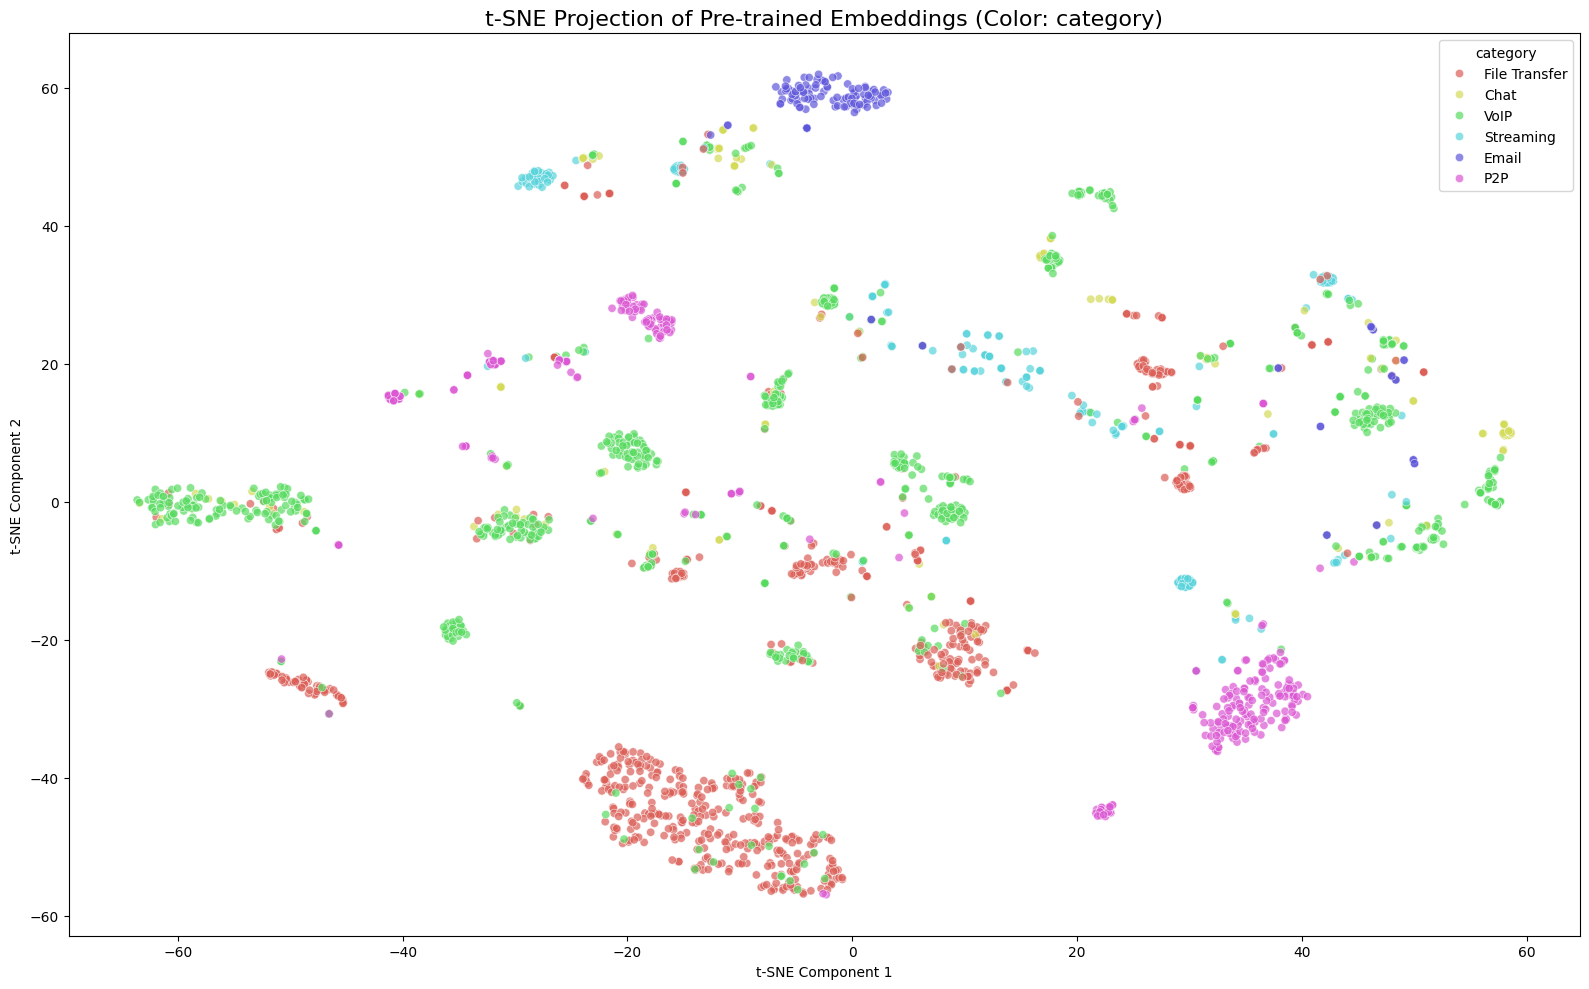

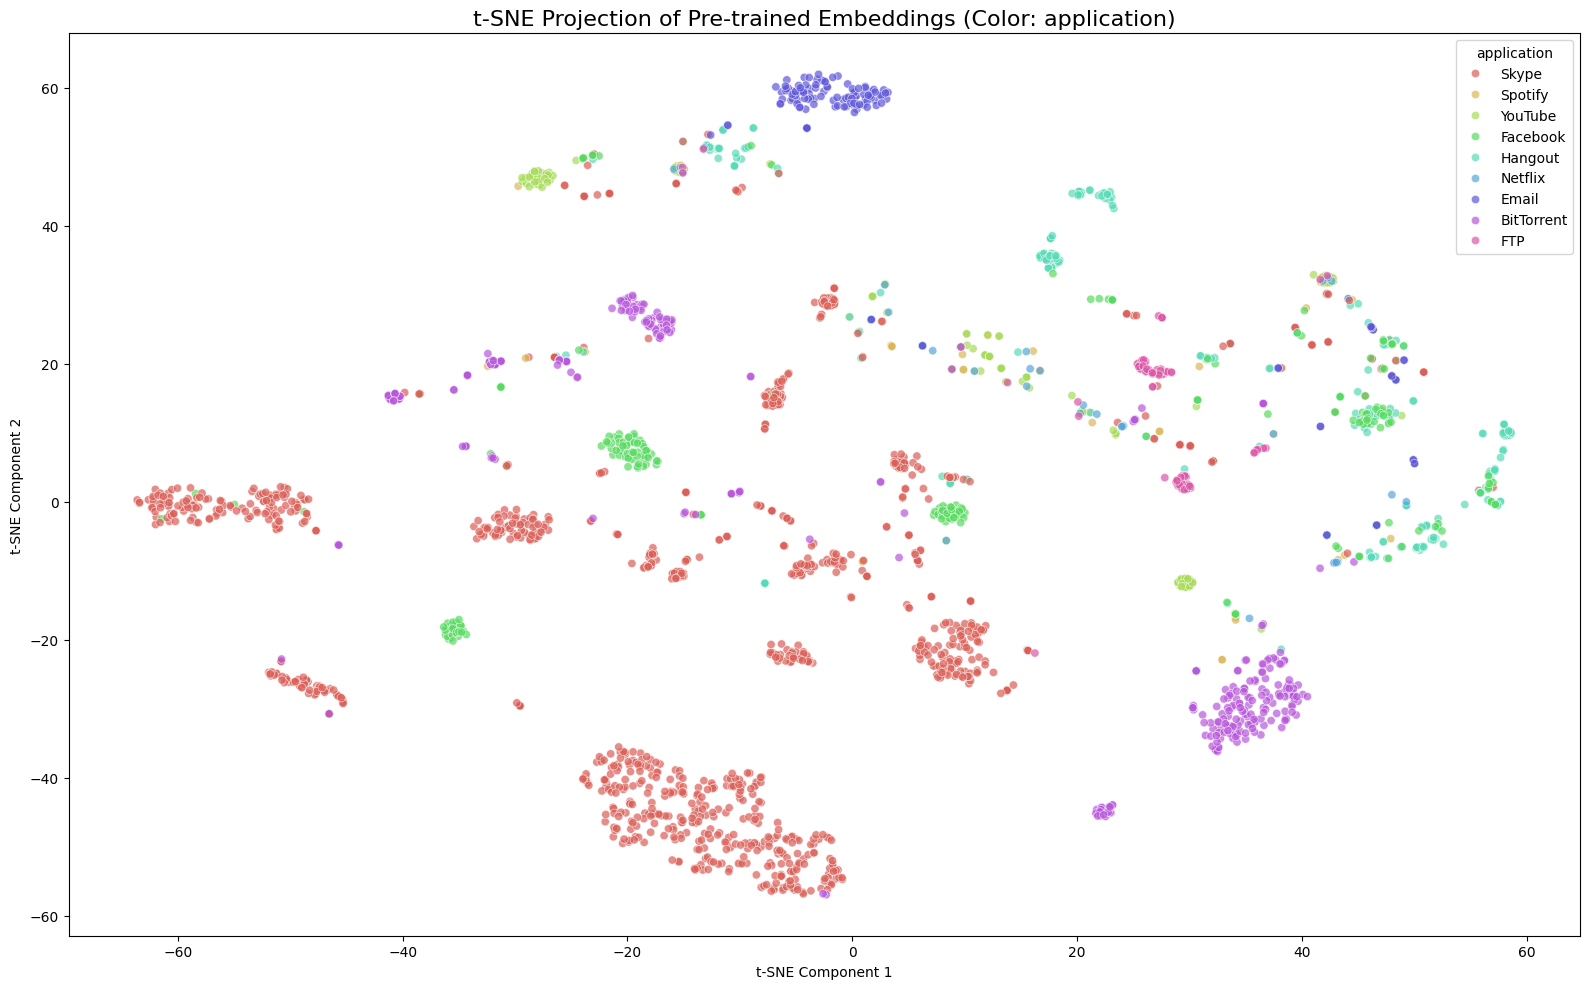

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Model
import os
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")

# How many samples to plot? (t-SNE is slow on >10k samples)
SAMPLE_SIZE = 3000
PERPLEXITY = 30     # Balance between local vs global structure (usually 5-50)

# --- 1. Define Architecture (Must match Pre-training exactly) ---
def get_cnn_encoder_full(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Reshape (10, 784) -> (7840, 1)
    x = layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)

    x = layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Flatten()(x)

    # Representation Layer (We want this one!)
    h = layers.Dense(128, activation='relu', name="representation")(x)

    # Projection Head (We ignore this for visualization)
    z = layers.Dense(64, activation='relu', name="projection")(h)

    return Model(inputs, [h, z])

def main():
    print("--- 1. Loading Data ---")
    X_data = np.load(X_VIEW1_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Randomly sample data to speed up t-SNE
    if len(X_data) > SAMPLE_SIZE:
        print(f"Dataset too large ({len(X_data)}), sampling {SAMPLE_SIZE} points...")
        indices = np.random.choice(len(X_data), SAMPLE_SIZE, replace=False)
        X_subset = X_data[indices]
        df_subset = df_labels.iloc[indices]
    else:
        X_subset = X_data
        df_subset = df_labels

    print("--- 2. Loading Pre-trained Encoder ---")
    # Load full architecture
    full_model = get_cnn_encoder_full((10, 784))
    full_model.load_weights(ENCODER_CNN_WEIGHTS)

    # Create a feature extractor that outputs 'h' (representation)
    # output index 0 is 'h', index 1 is 'z'
    feature_extractor = Model(inputs=full_model.input, outputs=full_model.outputs[0])

    print("Extracting features (embeddings)...")
    embeddings = feature_extractor.predict(X_subset, batch_size=128, verbose=1)
    # ... [Inside main(), after feature_extractor.predict] ...

    print(f"Embeddings Shape: {embeddings.shape}") # Should be (N, 128)

    # --- START OF FIX ---
    # Check for NaNs or Infinity
    if np.isnan(embeddings).any() or np.isinf(embeddings).any():
        print("⚠️ Warning: NaN or Inf values detected in embeddings!")

        # Identify valid rows (rows that do NOT contain any NaN or Inf)
        valid_rows = ~np.isnan(embeddings).any(axis=1) & ~np.isinf(embeddings).any(axis=1)

        n_dropped = len(embeddings) - np.sum(valid_rows)
        print(f"   -> Dropping {n_dropped} corrupted samples...")

        # If ALL rows are bad, the model is broken
        if np.sum(valid_rows) == 0:
            print("❌ FATAL: All embeddings are corrupted.")
            print("   Reason: Your pre-training likely suffered 'Gradient Explosion'.")
            print("   Solution: Retrain 'Script 2' with a lower learning rate (e.g., 0.0001).")
            return

        # Filter both embeddings and the corresponding labels
        embeddings = embeddings[valid_rows]
        df_subset = df_subset.iloc[valid_rows] # Match the labels to the clean data

        print(f"   -> New Shape: {embeddings.shape}")
    # --- END OF FIX ---

    print("--- 3. Running t-SNE (Dimensionality Reduction) ---")
    tsne = TSNE(n_components=2, verbose=1, perplexity=PERPLEXITY, max_iter=1000, random_state=42)
    tsne_results = tsne.fit_transform(embeddings)

    # ... [Continue with the rest of the script] ...

    # Add t-SNE results to dataframe for plotting
    df_subset['tsne-2d-one'] = tsne_results[:,0]
    df_subset['tsne-2d-two'] = tsne_results[:,1]

    print("--- 4. Plotting ---")

    # Define what we want to color by
    plot_types = ['category', 'application']

    for label_col in plot_types:
        if label_col not in df_subset.columns:
            continue

        plt.figure(figsize=(16, 10))

        # Create Scatter Plot
        sns.scatterplot(
            x="tsne-2d-one", y="tsne-2d-two",
            hue=label_col,
            palette=sns.color_palette("hls", df_subset[label_col].nunique()),
            data=df_subset,
            legend="full",
            alpha=0.7
        )

        plt.title(f"t-SNE Projection of Pre-trained Embeddings (Color: {label_col})", fontsize=16)
        plt.xlabel("t-SNE Component 1")
        plt.ylabel("t-SNE Component 2")

        # Move legend outside if too many classes
        if df_subset[label_col].nunique() > 10:
             plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model
import numpy as np
import os

# --- CONFIG ---
LATENT_DIM = 128
PROJECTION_DIM = 64
TEMPERATURE = 0.1
BATCH_SIZE = 64
EPOCHS = 30         # Reduced epochs since we are fixing the learning
LEARNING_RATE = 0.0001 # Reduced LR to prevent explosion

# --- PATHS ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
ENCODER_CNN_SAVE = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN.weights.h5")
ENCODER_MLP_SAVE = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_MLP.weights.h5")



def get_cnn_encoder(input_shape):
    # This is your Alpha architecture (minus the softmax)
    inputs = layers.Input(shape=input_shape)

    # Reshape (10, 784) -> (7840, 1) just like alpha2.py
    x = layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)

    x = layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Flatten()(x)

    # Representation Layer
    h = layers.Dense(LATENT_DIM, activation='relu')(x)

    # Projection Head (Only used for Contrastive Loss training)
    z = layers.Dense(PROJECTION_DIM, activation='relu')(h)
    z = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))(z) # Normalize

    return Model(inputs, [h, z], name="Encoder_CNN")

def get_mlp_encoder(input_dim):
    # This processes Beta + Gamma + FFT
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)

    # Representation Layer
    h = layers.Dense(LATENT_DIM, activation='relu')(x)

    # Projection Head
    z = layers.Dense(PROJECTION_DIM, activation='relu')(h)
    z = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))(z) # Normalize

    return Model(inputs, [h, z], name="Encoder_MLP")

# --- Contrastive Loss (Keep same) ---
def nt_xent_loss(z1, z2, temperature):
    # (Copy the function from your previous script)
    # ... implementation ...
    batch_size = tf.shape(z1)[0]
    z = tf.concat([z1, z2], axis=0)
    sim_matrix = tf.matmul(z, z, transpose_b=True) / temperature
    labels = tf.range(2 * batch_size)
    mask = tf.one_hot(labels, 2 * batch_size)
    logits = sim_matrix - mask * 1e9
    labels_1 = labels + batch_size
    labels_2 = labels - batch_size
    labels_1 = tf.boolean_mask(labels_1, labels_1 < 2 * batch_size)
    labels_2 = tf.boolean_mask(labels_2, labels_2 >= 0)
    true_labels = tf.concat([labels_1, labels_2], axis=0)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=true_labels, logits=logits)
    return tf.reduce_mean(loss)

# --- 2. The H-MVCL Model Wrapper (Fixed) ---

class HMVCL_Model(models.Model):
    def __init__(self, cnn_encoder, mlp_encoder, temperature=0.1):
        super(HMVCL_Model, self).__init__()
        self.cnn_encoder = cnn_encoder
        self.mlp_encoder = mlp_encoder
        self.temperature = temperature

    def compile(self, optimizer, loss_fn):
        super(HMVCL_Model, self).compile()
        self.optimizer = optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        x_view1, x_view2 = data

        with tf.GradientTape() as tape:
            # Forward pass both views
            _, z1 = self.cnn_encoder(x_view1, training=True)
            _, z2 = self.mlp_encoder(x_view2, training=True)

            # Calculate Contrastive Loss
            loss = self.loss_fn(z1, z2, self.temperature)

        # Update weights
        trainable_vars = self.cnn_encoder.trainable_variables + self.mlp_encoder.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Clip Gradients (This is the real protection against NaNs)
        gradients, _ = tf.clip_by_global_norm(gradients, 1.0)

        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        return {"loss": loss}

def main():
    print("--- Loading Aligned Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32') # (N, 10, 784)
    X_view2 = np.load(X_VIEW2_PATH).astype('float32') # (N, Features)

    # --- 1. DIAGNOSIS & CLEANING ---
    print(f"Original Shapes -> View 1: {X_view1.shape}, View 2: {X_view2.shape}")

    # Check View 1 (CNN Inputs)
    if np.isnan(X_view1).any() or np.isinf(X_view1).any():
        print("⚠️  WARNING: View 1 (CNN) contains NaNs or Infinity!")
        count = np.isnan(X_view1).sum()
        print(f"   -> Found {count} bad values. Replacing with 0...")
        X_view1 = np.nan_to_num(X_view1, nan=0.0, posinf=1.0, neginf=0.0)

    # Check View 2 (Stats Inputs)
    if np.isnan(X_view2).any() or np.isinf(X_view2).any():
        print("⚠️  WARNING: View 2 (Stats) contains NaNs or Infinity!")
        count = np.isnan(X_view2).sum()
        print(f"   -> Found {count} bad values. Replacing with 0...")
        X_view2 = np.nan_to_num(X_view2, nan=0.0, posinf=0.0, neginf=0.0)

    # --- 2. NORMALIZATION ---

    # Normalize View 1 (0-255 -> 0-1)
    print("Normalizing View 1...")
    X_view1 = X_view1 / 255.0

    # Normalize View 2 (Standard Scaling)
    # Note: We must handle columns where std=0 (constant values) to avoid creating new NaNs
    print("Normalizing View 2...")
    mean = np.mean(X_view2, axis=0)
    std = np.std(X_view2, axis=0)

    # Fix: If std is 0, replace with 1 to avoid DivisionByZero
    std[std == 0] = 1.0

    X_view2 = (X_view2 - mean) / std

    # Final Safety Check
    if np.isnan(X_view1).any() or np.isnan(X_view2).any():
        print("❌ FATAL: Data still contains NaNs after normalization.")
        print("   This implies a massive corruption in your dataset source.")
        return

    print("✅ Data Clean and Normalized. Starting Training...")

    # Create Encoders
    # Note: Make sure input_shape matches your data (10, 784)
    cnn = get_cnn_encoder(input_shape=(10, 784))
    mlp = get_mlp_encoder(input_dim=X_view2.shape[1])

    hmvcl = HMVCL_Model(cnn, mlp, temperature=TEMPERATURE)

    # --- CRITICAL FIX 2: Lower LR and Clipnorm ---
    hmvcl.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss_fn=nt_xent_loss
    )

    dataset = tf.data.Dataset.from_tensor_slices(((X_view1, X_view2)))
    dataset = dataset.shuffle(1024).batch(BATCH_SIZE)

    print("--- Starting Contrastive Pre-Training ---")
    try:
        hmvcl.fit(dataset, epochs=EPOCHS)
    except Exception as e:
        print(f"Training crashed: {e}")
        return

    print("--- Saving Encoder Weights ---")
    cnn.save_weights(ENCODER_CNN_SAVE)
    mlp.save_weights(ENCODER_MLP_SAVE)
    print("Done.")

# Include your encoder definitions here before running main
# ...

if __name__ == "__main__":
    main()

--- Loading Aligned Data ---
Original Shapes -> View 1: (2623, 10, 784), View 2: (2623, 100)
⚠️  WARNING: View 2 (Stats) contains NaNs or Infinity!
   -> Found 790 bad values. Replacing with 0...
Normalizing View 1...
Normalizing View 2...
✅ Data Clean and Normalized. Starting Training...
--- Starting Contrastive Pre-Training ---
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 364ms/step - loss: 4.8180
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9582
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.5869
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.3492
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1500
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9804
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8892
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7804
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7056
Epoch 10/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6472
Epoch

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.10  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 262, Test Size: 2361
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.8784
               precision    recall  f1-score   support

         Chat       0.59      0.59      0.59       138
        Email       0.86      0.90      0.88       120
File Transfer       0.88      0.89      0.88       732
          P2P       0.89      0.95      0.92       325
    Streaming       0.85      0.92      0.89       232
         VoIP       0.94      0.88      0.91       814

     accuracy                           0.88      2361
    macro avg       0.84      0.85      0.84      2361
 weighted avg       0.88      0.88      0.88      2361


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8297
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.10  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 262, Test Size: 2361
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.8707
               precision    recall  f1-score   support

         Chat       0.59      0.59      0.59       138
        Email       0.78      0.91      0.84       120
File Transfer       0.87      0.88      0.88       732
          P2P       0.89      0.93      0.91       325
    Streaming       0.86      0.89      0.88       232
         VoIP       0.93      0.87      0.90       814

     accuracy                           0.87      2361
    macro avg       0.82      0.85      0.83      2361
 weighted avg       0.87      0.87      0.87      2361


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8366
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.20  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 524, Test Size: 2099
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.9039
               precision    recall  f1-score   support

         Chat       0.59      0.70      0.64       122
        Email       0.89      0.92      0.91       106
File Transfer       0.90      0.90      0.90       650
          P2P       0.96      0.99      0.97       289
    Streaming       0.91      0.89      0.90       207
         VoIP       0.95      0.91      0.93       725

     accuracy                           0.90      2099
    macro avg       0.86      0.88      0.87      2099
 weighted avg       0.91      0.90      0.90      2099


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8599
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.30  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 786, Test Size: 1837
Skipping Binary Task (Column 'binary_type' not found)

=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.9148
               precision    recall  f1-score   support

         Chat       0.59      0.81      0.68       101
        Email       0.87      0.97      0.91        93
File Transfer       0.92      0.89      0.91       567
          P2P       0.96      0.97      0.97       253
    Streaming       0.92      0.90      0.91       181
         VoIP       0.96      0.92      0.94       642

     accuracy                           0.91      1837
    macro avg       0.87      0.91      0.89      1837
 weighted avg       0.92      0.91      0.91      1837


=== Training Task: Application ===
   Applying SMOTE for Application...
   ! SMOTE failed (too few samples). Using original data.
   >>> Application Weighted F1: 0.8811
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.30  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 2862, Test Size: 6680

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9656
              precision    recall  f1-score   support

      NonVPN       0.98      0.97      0.98      5350
         VPN       0.89      0.94      0.91      1330

    accuracy                           0.97      6680
   macro avg       0.94      0.95      0.95      6680
weighted avg       0.97      0.97      0.97      6680


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7456
               precision    recall  f1-score   support

         Chat       0.63      0.93      0.75      1602
        Email       0.87      0.23      0.37      1275
File Transfer       0.87      0.89      0.88      1635
          P2P       0.98      0.97      0.97       253
    Streaming       0.66      0.92      0.77       206
         VoIP       0.85      0.87      0.86      1709

     

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.05  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 477, Test Size: 9065

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9256
              precision    recall  f1-score   support

      NonVPN       0.96      0.95      0.95      7270
         VPN       0.80      0.83      0.81      1795

    accuracy                           0.93      9065
   macro avg       0.88      0.89      0.88      9065
weighted avg       0.93      0.93      0.93      9065


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.6966
               precision    recall  f1-score   support

         Chat       0.60      0.89      0.72      2160
        Email       0.66      0.21      0.32      1731
File Transfer       0.81      0.82      0.81      2233
          P2P       0.95      0.93      0.94       343
    Streaming       0.63      0.72      0.67       280
         VoIP       0.80      0.82      0.81      2318

     a

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.1  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 954, Test Size: 8588

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9428
              precision    recall  f1-score   support

      NonVPN       0.97      0.96      0.96      6878
         VPN       0.85      0.86      0.86      1710

    accuracy                           0.94      8588
   macro avg       0.91      0.91      0.91      8588
weighted avg       0.94      0.94      0.94      8588


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7181
               precision    recall  f1-score   support

         Chat       0.61      0.90      0.73      2043
        Email       0.76      0.23      0.35      1640
File Transfer       0.86      0.84      0.85      2125
          P2P       0.91      0.93      0.92       325
    Streaming       0.58      0.85      0.69       266
         VoIP       0.81      0.85      0.83      2189

     a

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.2  # 5% Label Scarcity

# --- Helper: Generic Trainer ---
def train_task_head(X_train, y_train, X_test, y_test, task_name, use_smote=False):
    print(f"\n=== Training Task: {task_name} ===")

    # 1. Handle Class Imbalance
    if use_smote:
        print(f"   Applying SMOTE for {task_name}...")
        # k_neighbors=1 is safe for extremely rare classes
        smote = SMOTE(k_neighbors=1, random_state=42)
        try:
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        except ValueError:
             # Fallback if a class has < 2 samples
            print("   ! SMOTE failed (too few samples). Using original data.")
            X_train_bal, y_train_bal = X_train, y_train
    else:
        X_train_bal, y_train_bal = X_train, y_train

    # 2. Compute Weights (Double protection)
    weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

    # 3. Train XGBoost
    clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss' # or 'logloss' for binary
    )
    clf.fit(X_train_bal, y_train_bal, sample_weight=weights)

    # 4. Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"   >>> {task_name} Weighted F1: {f1:.4f}")
    return clf, y_pred

def get_cnn_encoder_full(input_shape):
    # Definition must match exactly
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return Model(inputs, [h, z])

def main():
    # --- 1. Load & Fuse Data ---
    print("--- Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X_view2 = (X_view2 - np.mean(X_view2, axis=0)) / (np.std(X_view2, axis=0) + 1e-8)

    # Extract CNN
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    # Final Embeddings
    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. Data Splitting ---
    # We must use the SAME indices for all tasks to ensure fair comparison
    # We create a generic split based on indices
    indices = np.arange(len(X_final))

    # Stratify based on Application (the most detailed label)
    # This ensures rare apps (Netflix) exist in both Train and Test
    y_stratify = LabelEncoder().fit_transform(df_labels['application'])

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_stratify
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")

    # --- TASK 1: BINARY (VPN vs Non-VPN) ---
    if 'binary_type' in df_labels.columns:
        le_bin = LabelEncoder()
        y_bin = le_bin.fit_transform(df_labels['binary_type'])
        y_train_bin, y_test_bin = y_bin[train_idx], y_bin[test_idx]

        # Train (Binary usually doesn't need SMOTE)
        clf_bin, preds_bin = train_task_head(X_train, y_train_bin, X_test, y_test_bin, "Binary", use_smote=False)
        print(classification_report(y_test_bin, preds_bin, target_names=le_bin.classes_))
    else:
        print("Skipping Binary Task (Column 'binary_type' not found)")

    # --- TASK 2: CATEGORY (Streaming, VoIP, etc.) ---
    if 'category' in df_labels.columns:
        le_cat = LabelEncoder()
        y_cat = le_cat.fit_transform(df_labels['category'])
        y_train_cat, y_test_cat = y_cat[train_idx], y_cat[test_idx]

        # Train (Use SMOTE because Streaming category might be small in 5% split)
        clf_cat, preds_cat = train_task_head(X_train, y_train_cat, X_test, y_test_cat, "Category", use_smote=True)
        print(classification_report(y_test_cat, preds_cat, target_names=le_cat.classes_))

    # --- TASK 3: APPLICATION (Netflix, Skype, etc.) ---
    le_app = LabelEncoder()
    y_app = le_app.fit_transform(df_labels['application'])
    y_train_app, y_test_app = y_app[train_idx], y_app[test_idx]

    # Train (Definitely need SMOTE)
    clf_app, preds_app = train_task_head(X_train, y_train_app, X_test, y_test_app, "Application", use_smote=True)
    print(classification_report(y_test_app, preds_app, target_names=le_app.classes_))

if __name__ == "__main__":
    main()

--- Loading Data ---
Train Size: 1908, Test Size: 7634

=== Training Task: Binary ===
   >>> Binary Weighted F1: 0.9619
              precision    recall  f1-score   support

      NonVPN       0.98      0.97      0.98      6113
         VPN       0.89      0.92      0.91      1521

    accuracy                           0.96      7634
   macro avg       0.93      0.95      0.94      7634
weighted avg       0.96      0.96      0.96      7634


=== Training Task: Category ===
   Applying SMOTE for Category...
   ! SMOTE failed (too few samples). Using original data.
   >>> Category Weighted F1: 0.7331
               precision    recall  f1-score   support

         Chat       0.62      0.91      0.74      1824
        Email       0.87      0.22      0.36      1458
File Transfer       0.85      0.87      0.86      1871
          P2P       0.98      0.93      0.96       289
    Streaming       0.64      0.92      0.76       236
         VoIP       0.83      0.87      0.85      1956

     

--- 1. Loading Data ---
--- 2. Loading Pre-trained Encoder ---
Extracting features (embeddings)...
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
Embeddings Shape: (2623, 128)
--- 3. Running t-SNE (Dimensionality Reduction) ---
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2623 samples in 0.001s...
[t-SNE] Computed neighbors for 2623 samples in 0.110s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2623
[t-SNE] Computed conditional probabilities for sample 2000 / 2623
[t-SNE] Computed conditional probabilities for sample 2623 / 2623
[t-SNE] Mean sigma: 0.010970
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.762112
[t-SNE] KL divergence after 1000 iterations: 0.535991
--- 4. Plotting ---


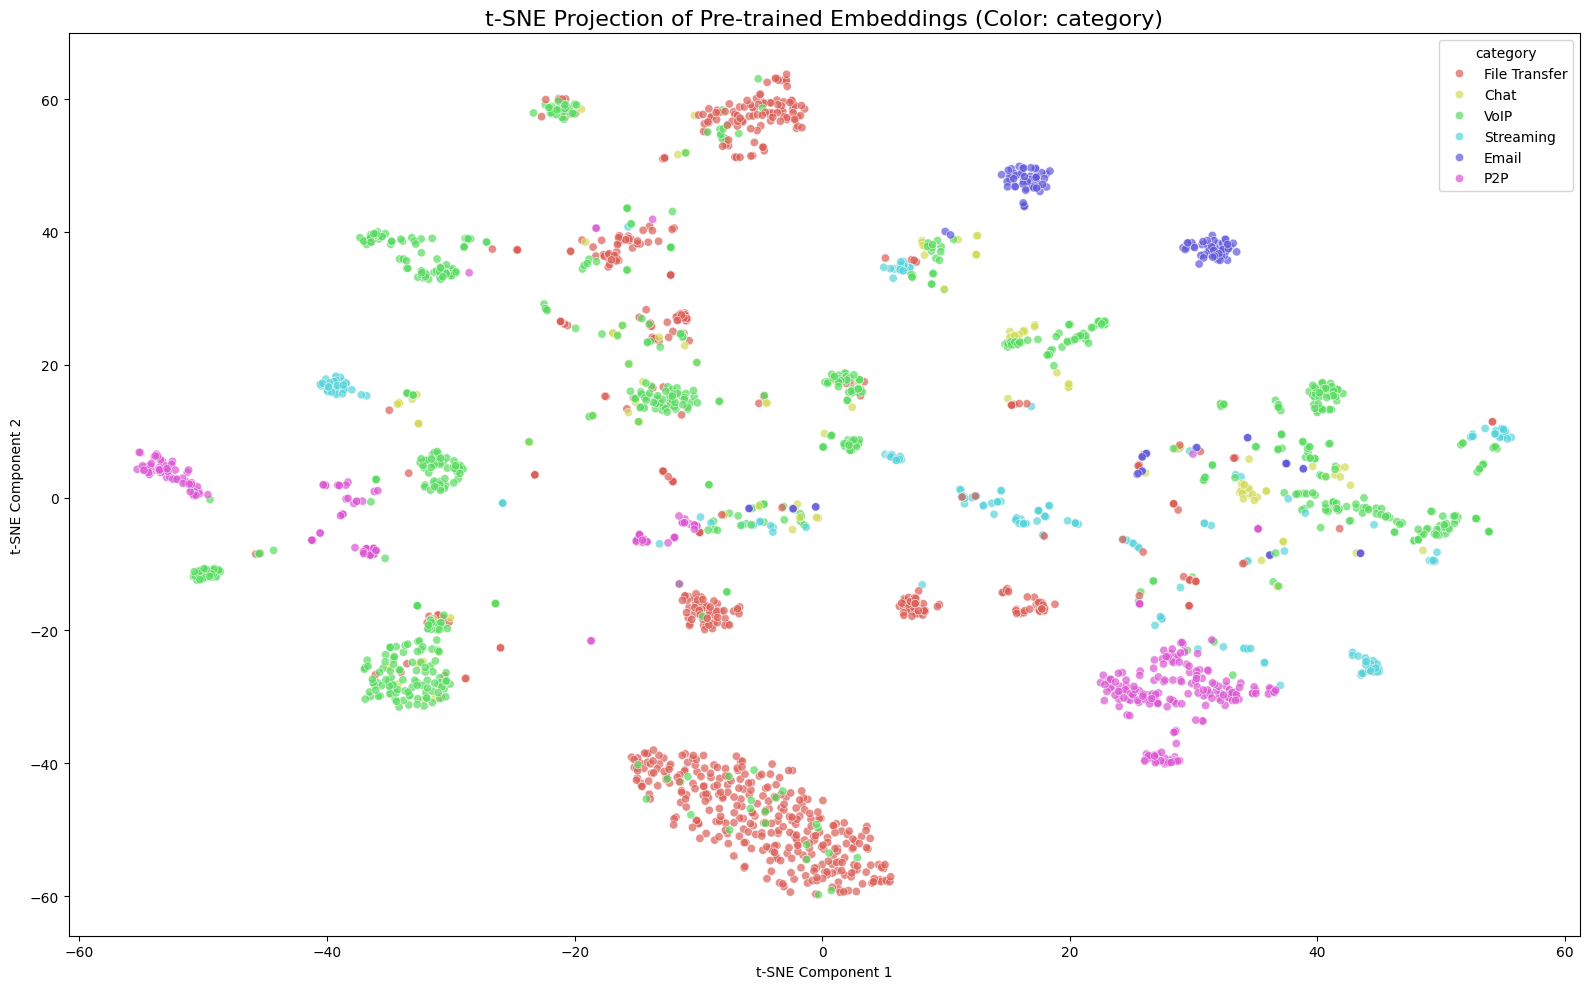

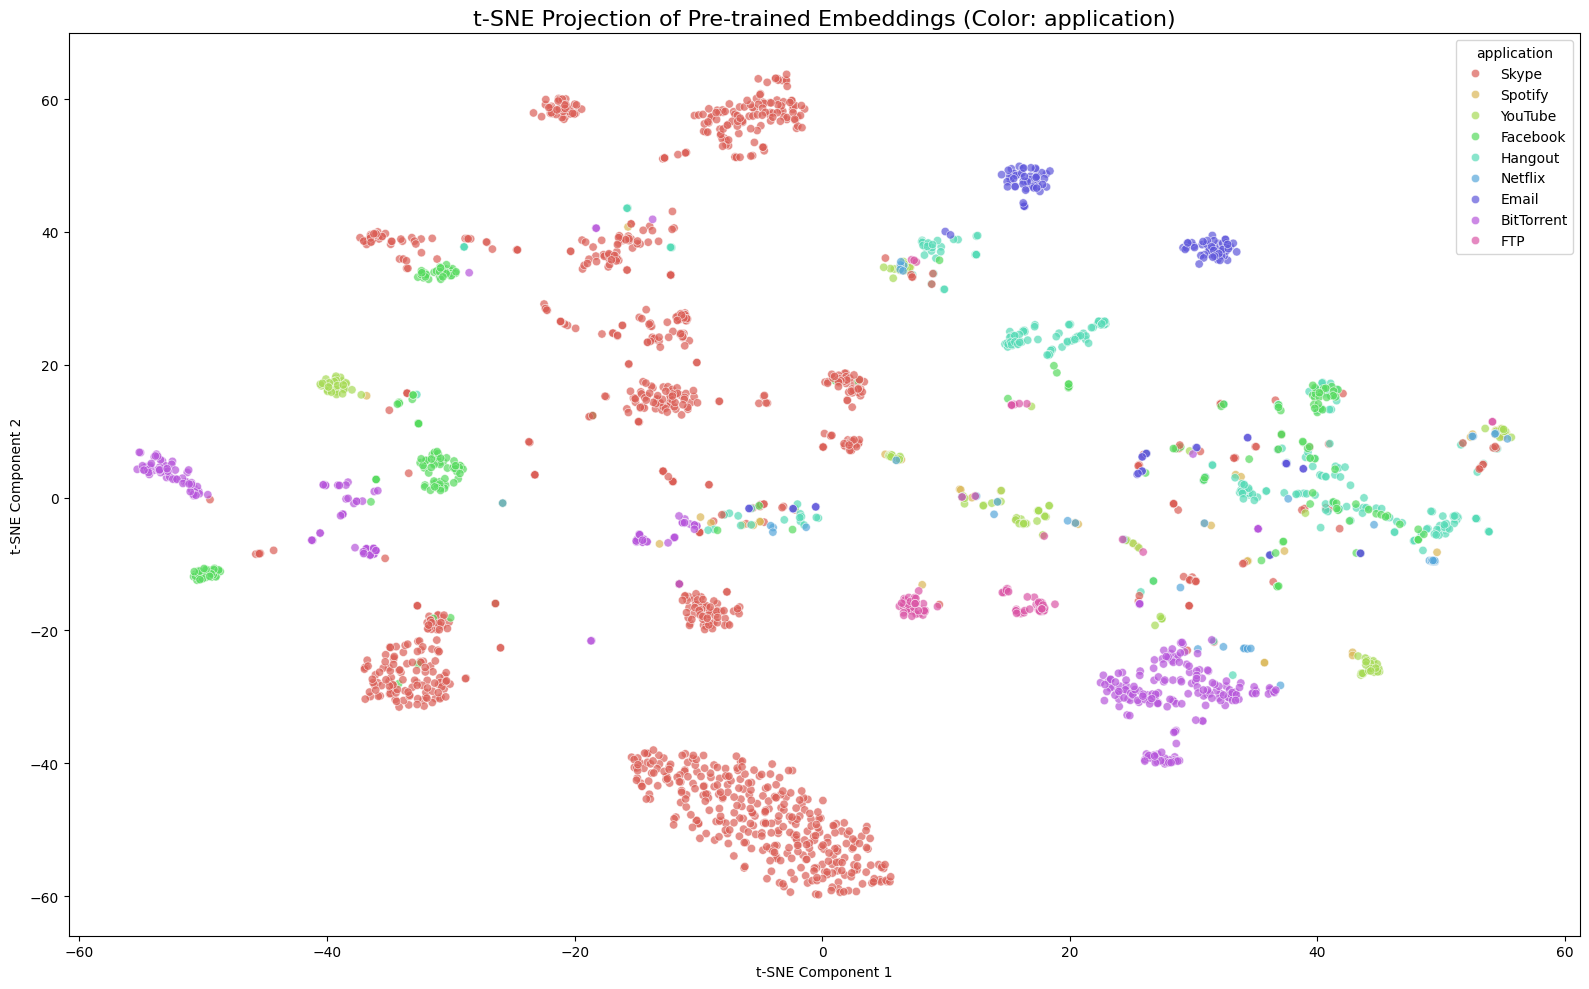

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Model
import os
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy") # Changed this line
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

# How many samples to plot? (t-SNE is slow on >10k samples)
SAMPLE_SIZE = 3000
PERPLEXITY = 30     # Balance between local vs global structure (usually 5-50)

# --- 1. Define Architecture (Must match Pre-training exactly) ---
def get_cnn_encoder_full(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Reshape (10, 784) -> (7840, 1)
    x = layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)

    x = layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Flatten()(x)

    # Representation Layer (We want this one!)
    h = layers.Dense(128, activation='relu', name="representation")(x)

    # Projection Head (We ignore this for visualization)
    z = layers.Dense(64, activation='relu', name="projection")(h)

    return Model(inputs, [h, z])

def main():
    print("--- 1. Loading Data ---")
    X_data = np.load(X_VIEW1_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # Randomly sample data to speed up t-SNE
    if len(X_data) > SAMPLE_SIZE:
        print(f"Dataset too large ({len(X_data)}), sampling {SAMPLE_SIZE} points...")
        indices = np.random.choice(len(X_data), SAMPLE_SIZE, replace=False)
        X_subset = X_data[indices]
        df_subset = df_labels.iloc[indices]
    else:
        X_subset = X_data
        df_subset = df_labels

    print("--- 2. Loading Pre-trained Encoder ---")
    # Load full architecture
    full_model = get_cnn_encoder_full((10, 784))
    full_model.load_weights(ENCODER_CNN_WEIGHTS)

    # Create a feature extractor that outputs 'h' (representation)
    # output index 0 is 'h', index 1 is 'z'
    feature_extractor = Model(inputs=full_model.input, outputs=full_model.outputs[0])

    print("Extracting features (embeddings)...")
    embeddings = feature_extractor.predict(X_subset, batch_size=128, verbose=1)
    # ... [Inside main(), after feature_extractor.predict] ...

    print(f"Embeddings Shape: {embeddings.shape}") # Should be (N, 128)

    # --- START OF FIX ---
    # Check for NaNs or Infinity
    if np.isnan(embeddings).any() or np.isinf(embeddings).any():
        print("⚠️ Warning: NaN or Inf values detected in embeddings!")

        # Identify valid rows (rows that do NOT contain any NaN or Inf)
        valid_rows = ~np.isnan(embeddings).any(axis=1) & ~np.isinf(embeddings).any(axis=1)

        n_dropped = len(embeddings) - np.sum(valid_rows)
        print(f"   -> Dropping {n_dropped} corrupted samples...")

        # If ALL rows are bad, the model is broken
        if np.sum(valid_rows) == 0:
            print("❌ FATAL: All embeddings are corrupted.")
            print("   Reason: Your pre-training likely suffered 'Gradient Explosion'.")
            print("   Solution: Retrain 'Script 2' with a lower learning rate (e.g., 0.0001).")
            return

        # Filter both embeddings and the corresponding labels
        embeddings = embeddings[valid_rows]
        df_subset = df_subset.iloc[valid_rows] # Match the labels to the clean data

        print(f"   -> New Shape: {embeddings.shape}")
    # --- END OF FIX ---

    print("--- 3. Running t-SNE (Dimensionality Reduction) ---")
    tsne = TSNE(n_components=2, verbose=1, perplexity=PERPLEXITY, max_iter=1000, random_state=42)
    tsne_results = tsne.fit_transform(embeddings)

    # ... [Continue with the rest of the script] ...

    # Add t-SNE results to dataframe for plotting
    df_subset['tsne-2d-one'] = tsne_results[:,0]
    df_subset['tsne-2d-two'] = tsne_results[:,1]

    print("--- 4. Plotting ---")

    # Define what we want to color by
    plot_types = ['category', 'application']

    for label_col in plot_types:
        if label_col not in df_subset.columns:
            continue

        plt.figure(figsize=(16, 10))

        # Create Scatter Plot
        sns.scatterplot(
            x="tsne-2d-one", y="tsne-2d-two",
            hue=label_col,
            palette=sns.color_palette("hls", df_subset[label_col].nunique()),
            data=df_subset,
            legend="full",
            alpha=0.7
        )

        plt.title(f"t-SNE Projection of Pre-trained Embeddings (Color: {label_col})", fontsize=16)
        plt.xlabel("t-SNE Component 1")
        plt.ylabel("t-SNE Component 2")

        # Move legend outside if too many classes
        if df_subset[label_col].nunique() > 10:
             plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.20

def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu')(x)
    z = tf.keras.layers.Dense(64, activation='relu')(h)
    return Model(inputs, [h, z])

def main():
    print("--- 1. Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # --- FIX 1: CLEAN & NORMALIZE ---
    print("   Cleaning Stats (Removing NaNs)...")
    # 1. Replace Infinite with NaN
    X_view2 = np.nan_to_num(X_view2, nan=0.0, posinf=0.0, neginf=0.0)

    # 2. Normalize (Z-Score)
    mean = np.mean(X_view2, axis=0)
    std = np.std(X_view2, axis=0) + 1e-8 # Add epsilon to prevent div/0
    X_view2 = (X_view2 - mean) / std

    # 3. Final Safety Check (Replace any NaNs created by normalization)
    X_view2 = np.nan_to_num(X_view2, nan=0.0)

    # Extract CNN Embeddings
    print("   Extracting CNN Embeddings...")
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. CREATE COMPOSITE LABELS ---
    df_labels['composite_label'] = df_labels['application'] + "_" + df_labels['category']
    print(f"   Created {df_labels['composite_label'].nunique()} composite labels.")

    # Stratified Split
    y_composite = df_labels['composite_label'].values
    indices = np.arange(len(X_final))

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_composite
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train_comp = y_composite[train_idx]
    y_test_comp = y_composite[test_idx]

    # --- 3. ADAPTIVE SMOTE ---
    print("--- Applying Adaptive Sampling ---")

    # Check for NaNs one last time before SMOTE
    if np.isnan(X_train).any():
        print("FATAL: X_train still contains NaNs. Replacing with 0.")
        X_train = np.nan_to_num(X_train)

    try:
        # Try SMOTE first (Better quality)
        smote = SMOTE(k_neighbors=1, random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train_comp)
        print("   SMOTE Successful.")
    except Exception as e:
        # Fallback to Random Sampling (Safe)
        print(f"   SMOTE failed ({e}). Using RandomOverSampler.")
        ros = RandomOverSampler(random_state=42)
        X_train_res, y_train_res = ros.fit_resample(X_train, y_train_comp)

    # --- FIX 2: ENCODE LABELS ---
    print("--- Encoding Labels ---")
    le_comp = LabelEncoder()
    # Convert ["Skype_VoIP", ...] -> [0, 5, ...]
    y_train_enc = le_comp.fit_transform(y_train_res)

    # --- 4. TRAIN ---
    print(f"--- Training XGBoost on {len(y_train_enc)} samples ---")
    clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        objective='multi:softmax',  # Explicitly set for multi-class
        num_class=len(le_comp.classes_)
    )

    # Crucial: Use y_train_enc (integers), NOT y_train_res (strings)
    clf.fit(X_train_res, y_train_enc)

    # --- 5. EVALUATE ---
    print("--- Evaluating ---")
    y_pred_enc = clf.predict(X_test)
    y_pred_comp = le_comp.inverse_transform(y_pred_enc)

    # Map Composite back to Application for the Report
    y_test_app = [label.split('_')[0] for label in y_test_comp]
    y_pred_app = [label.split('_')[0] for label in y_pred_comp]

    print("\n=== FINAL APPLICATION RESULTS (Composite Training) ===")
    print(classification_report(y_test_app, y_pred_app))

if __name__ == "__main__":
    main()

--- 1. Loading Data ---
   Cleaning Stats (Removing NaNs)...
   Extracting CNN Embeddings...
   Created 13 composite labels.
--- Applying Adaptive Sampling ---
   SMOTE Successful.
--- Encoding Labels ---
--- Training XGBoost on 1859 samples ---
--- Evaluating ---

=== FINAL APPLICATION RESULTS (Composite Training) ===
              precision    recall  f1-score   support

  BitTorrent       0.95      0.97      0.96       289
       Email       0.82      0.92      0.87       106
         FTP       0.87      0.76      0.81        80
    Facebook       0.73      0.72      0.73       195
     Hangout       0.76      0.77      0.77       253
     Netflix       0.34      0.37      0.35        38
       Skype       0.95      0.93      0.94       969
     Spotify       0.31      0.27      0.29        52
     YouTube       0.65      0.71      0.68       117

    accuracy                           0.85      2099
   macro avg       0.71      0.71      0.71      2099
weighted avg       0.85      

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

LABEL_PERCENTAGE = 0.30

def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu')(x)
    z = tf.keras.layers.Dense(64, activation='relu')(h)
    return Model(inputs, [h, z])

def main():
    print("--- 1. Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # --- FIX 1: CLEAN & NORMALIZE ---
    print("   Cleaning Stats (Removing NaNs)...")
    # 1. Replace Infinite with NaN
    X_view2 = np.nan_to_num(X_view2, nan=0.0, posinf=0.0, neginf=0.0)

    # 2. Normalize (Z-Score)
    mean = np.mean(X_view2, axis=0)
    std = np.std(X_view2, axis=0) + 1e-8 # Add epsilon to prevent div/0
    X_view2 = (X_view2 - mean) / std

    # 3. Final Safety Check (Replace any NaNs created by normalization)
    X_view2 = np.nan_to_num(X_view2, nan=0.0)

    # Extract CNN Embeddings
    print("   Extracting CNN Embeddings...")
    cnn_full = get_cnn_encoder_full((10, 784))
    cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- 2. CREATE COMPOSITE LABELS ---
    df_labels['composite_label'] = df_labels['application'] + "_" + df_labels['category']
    print(f"   Created {df_labels['composite_label'].nunique()} composite labels.")

    # Stratified Split
    y_composite = df_labels['composite_label'].values
    indices = np.arange(len(X_final))

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_composite
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train_comp = y_composite[train_idx]
    y_test_comp = y_composite[test_idx]

    # --- 3. ADAPTIVE SMOTE ---
    print("--- Applying Adaptive Sampling ---")

    # Check for NaNs one last time before SMOTE
    if np.isnan(X_train).any():
        print("FATAL: X_train still contains NaNs. Replacing with 0.")
        X_train = np.nan_to_num(X_train)

    try:
        # Try SMOTE first (Better quality)
        smote = SMOTE(k_neighbors=1, random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train_comp)
        print("   SMOTE Successful.")
    except Exception as e:
        # Fallback to Random Sampling (Safe)
        print(f"   SMOTE failed ({e}). Using RandomOverSampler.")
        ros = RandomOverSampler(random_state=42)
        X_train_res, y_train_res = ros.fit_resample(X_train, y_train_comp)

    # --- FIX 2: ENCODE LABELS ---
    print("--- Encoding Labels ---")
    le_comp = LabelEncoder()
    # Convert ["Skype_VoIP", ...] -> [0, 5, ...]
    y_train_enc = le_comp.fit_transform(y_train_res)

    # --- 4. TRAIN ---
    print(f"--- Training XGBoost on {len(y_train_enc)} samples ---")
    clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        objective='multi:softmax',  # Explicitly set for multi-class
        num_class=len(le_comp.classes_)
    )

    # Crucial: Use y_train_enc (integers), NOT y_train_res (strings)
    clf.fit(X_train_res, y_train_enc)

    # --- 5. EVALUATE ---
    print("--- Evaluating ---")
    y_pred_enc = clf.predict(X_test)
    y_pred_comp = le_comp.inverse_transform(y_pred_enc)

    # Map Composite back to Application for the Report
    y_test_app = [label.split('_')[0] for label in y_test_comp]
    y_pred_app = [label.split('_')[0] for label in y_pred_comp]

    print("\n=== FINAL APPLICATION RESULTS (Composite Training) ===")
    print(classification_report(y_test_app, y_pred_app))

if __name__ == "__main__":
    main()

--- 1. Loading Data ---
   Cleaning Stats (Removing NaNs)...
   Extracting CNN Embeddings...
   Created 13 composite labels.
--- Applying Adaptive Sampling ---
   SMOTE Successful.
--- Encoding Labels ---
--- Training XGBoost on 2782 samples ---
--- Evaluating ---

=== FINAL APPLICATION RESULTS (Composite Training) ===
              precision    recall  f1-score   support

  BitTorrent       0.95      0.97      0.96       253
       Email       0.86      0.89      0.88        93
         FTP       0.93      0.91      0.92        70
    Facebook       0.79      0.81      0.80       171
     Hangout       0.85      0.77      0.81       221
     Netflix       0.54      0.45      0.49        33
       Skype       0.95      0.96      0.95       849
     Spotify       0.25      0.18      0.21        45
     YouTube       0.68      0.80      0.74       102

    accuracy                           0.88      1837
   macro avg       0.76      0.75      0.75      1837
weighted avg       0.88      

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2/"
X_VIEW1_PATH = os.path.join(BASE_PATH, "HMVCL_X_view1_alpha.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "HMVCL_y_labels.csv")
ENCODER_CNN_WEIGHTS = os.path.join(BASE_PATH, "FULL_HMVCL_Encoder_CNN2.weights.h5")

# Using the "Best" Setting (Experiment A Result)
LABEL_PERCENTAGE = 0.20

def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu')(x)
    z = tf.keras.layers.Dense(64, activation='relu')(h)
    return Model(inputs, [h, z])

def main():
    print("--- 1. Loading Data ---")
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')
    df_labels = pd.read_csv(Y_LABELS_PATH)

    # --- STEP A: DATA CLEANING (The Fix) ---
    print("--- Cleaning Statistical Data ---")

    # 1. Check for NaNs/Infs before doing anything
    if np.isnan(X_view2).any() or np.isinf(X_view2).any():
        print(f"   ! Detected dirty data. Cleaning...")
        # Replace NaN with 0, Inf with large numbers
        X_view2 = np.nan_to_num(X_view2, nan=0.0, posinf=1e5, neginf=-1e5)

    # 2. Normalize (Z-Score)
    # Add epsilon (1e-8) to std to avoid division by zero
    mean = np.mean(X_view2, axis=0)
    std = np.std(X_view2, axis=0) + 1e-8
    X_view2 = (X_view2 - mean) / std

    # 3. Double Check (Normalization might create new NaNs if column was all 0s)
    X_view2 = np.nan_to_num(X_view2, nan=0.0)

    print("   Data Cleaned & Normalized.")

    # --- STEP B: FEATURE FUSION ---
    print("--- Extracting CNN Embeddings ---")
    cnn_full = get_cnn_encoder_full((10, 784))
    try:
        cnn_full.load_weights(ENCODER_CNN_WEIGHTS)
    except Exception as e:
        print(f"FATAL: Weights not found at {ENCODER_CNN_WEIGHTS}")
        return

    cnn_extractor = Model(inputs=cnn_full.input, outputs=cnn_full.outputs[0])
    h_cnn = cnn_extractor.predict(X_view1, batch_size=128, verbose=0)

    X_final = np.concatenate([X_view2, h_cnn], axis=1)

    # --- STEP C: SPLIT ---
    # We are going back to "Application" Labels (Not Composite) based on your decision
    y_labels = LabelEncoder().fit_transform(df_labels['application'])
    indices = np.arange(len(X_final))

    train_idx, test_idx = train_test_split(
        indices, train_size=LABEL_PERCENTAGE,
        random_state=42, stratify=y_labels
    )

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y_labels[train_idx], y_labels[test_idx]

    # --- STEP D: ADAPTIVE SAMPLING ---
    print("--- Handling Class Imbalance ---")
    # Check for NaNs one last time in training data specifically
    X_train = np.nan_to_num(X_train, nan=0.0)

    try:
        # Try SMOTE first
        smote = SMOTE(k_neighbors=1, random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print("   SMOTE applied successfully.")
    except Exception as e:
        # Fallback to Random Oversampling
        print(f"   SMOTE not suitable ({e}). Using RandomOverSampler.")
        ros = RandomOverSampler(random_state=42)
        X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

    # --- STEP E: TRAIN ---
    print(f"--- Training XGBoost on {len(y_train_res)} samples ---")
    clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        objective='multi:softmax',
        num_class=len(np.unique(y_labels))
    )

    clf.fit(X_train_res, y_train_res)

    # --- STEP F: EVALUATE ---
    print("--- Evaluating ---")
    y_pred = clf.predict(X_test)

    # Convert back to string labels for report
    le = LabelEncoder()
    le.fit(df_labels['application'])
    target_names = [str(cls) for cls in le.classes_]

    print("\n=== FINAL ROBUST RESULTS ===")
    print(classification_report(y_test, y_pred, target_names=target_names))

if __name__ == "__main__":
    main()

--- 1. Loading Data ---
--- Cleaning Statistical Data ---
   ! Detected dirty data. Cleaning...
   Data Cleaned & Normalized.
--- Extracting CNN Embeddings ---
--- Handling Class Imbalance ---
   SMOTE applied successfully.
--- Training XGBoost on 2178 samples ---
--- Evaluating ---

=== FINAL ROBUST RESULTS ===
              precision    recall  f1-score   support

  BitTorrent       0.91      0.97      0.94       289
       Email       0.78      0.93      0.85       106
         FTP       0.92      0.74      0.82        80
    Facebook       0.78      0.69      0.73       195
     Hangout       0.74      0.82      0.78       253
     Netflix       0.42      0.39      0.41        38
       Skype       0.96      0.92      0.94       969
     Spotify       0.23      0.27      0.25        52
     YouTube       0.69      0.71      0.70       117

    accuracy                           0.85      2099
   macro avg       0.71      0.72      0.71      2099
weighted avg       0.85      0.85   

In [6]:
import numpy as np
import os

# --- CONFIG ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2"
X_VIEW2_PATH = os.path.join(BASE_PATH, "HMVCL_X_view2_stats.npy")

def main():
    print(f"--- Checking for NaNs in {X_VIEW2_PATH} ---")

    if not os.path.exists(X_VIEW2_PATH):
        print("File not found.")
        return

    # Load Data
    X = np.load(X_VIEW2_PATH)
    total_rows = X.shape[0]
    total_features = X.shape[1]

    # 1. Count Total NaN values
    total_nans = np.isnan(X).sum()

    # 2. Count Infinite values
    total_infs = np.isinf(X).sum()

    # 3. Count Rows affected
    # (If a row has even one NaN, it counts as 1 bad row)
    rows_with_nan = np.isnan(X).any(axis=1).sum()

    print(f"\n=== DATA HEALTH REPORT ===")
    print(f"Total Samples (Rows):     {total_rows}")
    print(f"Total Features (Cols):    {total_features}")
    print(f"--------------------------")
    print(f"Total NaN Values:         {total_nans}")
    print(f"Total Infinite Values:    {total_infs}")
    print(f"--------------------------")
    print(f"Affected Rows:            {rows_with_nan}")
    print(f"Percentage Corrupted:     {(rows_with_nan / total_rows) * 100:.2f}%")

    if rows_with_nan > 0:
        print("\n[Analysis]")
        print("These NaNs are likely caused by 'Skewness' or 'Kurtosis' calculations")
        print("on flows with 0 variance (e.g., packets that are all the same size).")
        print("Your 'Robust Script' successfully cleaned these before training.")

if __name__ == "__main__":
    main()

--- Checking for NaNs in /content/drive/MyDrive/1 Skripsi/new approach v2/HMVCL_X_view2_stats.npy ---

=== DATA HEALTH REPORT ===
Total Samples (Rows):     2623
Total Features (Cols):    100
--------------------------
Total NaN Values:         790
Total Infinite Values:    0
--------------------------
Affected Rows:            239
Percentage Corrupted:     9.11%

[Analysis]
These NaNs are likely caused by 'Skewness' or 'Kurtosis' calculations
on flows with 0 variance (e.g., packets that are all the same size).
Your 'Robust Script' successfully cleaned these before training.


In [7]:
import numpy as np
import os

# --- CONFIG ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/new approach v2"
X_VIEW2_PATH = os.path.join(BASE_PATH, "FULL_HMVCL_X_view2_stats.npy")

def main():
    print(f"--- Checking for NaNs in {X_VIEW2_PATH} ---")

    if not os.path.exists(X_VIEW2_PATH):
        print("File not found.")
        return

    # Load Data
    X = np.load(X_VIEW2_PATH)
    total_rows = X.shape[0]
    total_features = X.shape[1]

    # 1. Count Total NaN values
    total_nans = np.isnan(X).sum()

    # 2. Count Infinite values
    total_infs = np.isinf(X).sum()

    # 3. Count Rows affected
    # (If a row has even one NaN, it counts as 1 bad row)
    rows_with_nan = np.isnan(X).any(axis=1).sum()

    print(f"\n=== DATA HEALTH REPORT ===")
    print(f"Total Samples (Rows):     {total_rows}")
    print(f"Total Features (Cols):    {total_features}")
    print(f"--------------------------")
    print(f"Total NaN Values:         {total_nans}")
    print(f"Total Infinite Values:    {total_infs}")
    print(f"--------------------------")
    print(f"Affected Rows:            {rows_with_nan}")
    print(f"Percentage Corrupted:     {(rows_with_nan / total_rows) * 100:.2f}%")

    if rows_with_nan > 0:
        print("\n[Analysis]")
        print("These NaNs are likely caused by 'Skewness' or 'Kurtosis' calculations")
        print("on flows with 0 variance (e.g., packets that are all the same size).")
        print("Your 'Robust Script' successfully cleaned these before training.")

if __name__ == "__main__":
    main()

--- Checking for NaNs in /content/drive/MyDrive/1 Skripsi/new approach v2/FULL_HMVCL_X_view2_stats.npy ---

=== DATA HEALTH REPORT ===
Total Samples (Rows):     9542
Total Features (Cols):    100
--------------------------
Total NaN Values:         2150
Total Infinite Values:    0
--------------------------
Affected Rows:            759
Percentage Corrupted:     7.95%

[Analysis]
These NaNs are likely caused by 'Skewness' or 'Kurtosis' calculations
on flows with 0 variance (e.g., packets that are all the same size).
Your 'Robust Script' successfully cleaned these before training.
